<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:115%; text-align:left">

<h3 align="left"><font color=#8502d1>Problem:</font></h3>

Welcome to our journey through a cool dataset all about flights! This dataset is like a big treasure chest, full of information about when flights leave, when they arrive, how long they're delayed, how far they go, and lots more. We'll be playing detective to spot patterns and find clues that help us figure out what makes flights late. So, let's buckle up and get ready for a fun ride through this flight data!

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:115%; text-align:left">

<h3 align="left"><font color=#8502d1>Objectives:</font></h3>
    
1. Data Understanding
2. Exploratory Data Analysis (EDA)
   - Univariate Analysis
   - Bivariate Analysis
   - Multivariate Analysis
3. Data Preprocessing
   - Irrelevant Features Removal
   - Missing Value Treatment
   - Outlier Treatment
   - Encoding Categorical Features
   - Time Feature Transformation
   - Feature Scaling
   - Transforming Skewed Features

<a id="import"></a>
# <p style="background-color:#8502d1; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 1 | Import Libraries</p>



In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
%matplotlib inline

In [2]:
# Set the resolution of the plotted figures
plt.rcParams['figure.dpi'] = 120

# Configure Seaborn plot styles: Set background color and use dark grid
sns.set(rc={'axes.facecolor': '#F3E8FF'}, style='darkgrid')

<a id="read"></a>
# <p style="background-color:#8502d1; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 2 | Read Dataset</p>



<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

First, I am going to load the dataset:

In [3]:
# Read dataset
df = pd.read_csv('/kaggle/input/flights/flights.csv')
df.head()

,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Dataset Description:</font></h2>
    
| __Variable__ | __Description__ |
|     :---      |       :---      |      
| __id__ | A unique identifier assigned to each flight record in this dataset. |                
| __year__ | The year in which the flight took place. The dataset includes flights from the year 2013 |                        
| __month__ | The month of the year in which the flight occurred, represented by an integer ranging from 1 (January) to 12 (December) |
| __day__ | The day of the month on which the flight took place, represented by an integer from 1 to 31 |
| __dep_time__ | The actual departure time of the flight, represented in 24-hour format (hhmm) |                     
| __sched_dep_time__ | The locally scheduled departure time of the flight, presented in a 24-hour format (hhmm) |
| __dep_delay__ | The delay in flight departure, calculated as the difference (in minutes) between the actual and scheduled departure times. Positive values indicate a delay, while negative values indicate an early departure. |  
| __arr_time__ | The actual arrival time of the flight, represented in 24-hour format (hhmm) |                      
| __sched_arr_time__ | The locally scheduled arrival time of the flight, presented in a 24-hour format (hhmm) |
| __arr_delay__ |  The delay in flight arrival, calculated as the difference (in minutes) between the actual and scheduled arrival times. Positive values indicate a delay, while negative values indicate an early arrival |
| __carrier__ |  A two-letter code representing the airline carrier responsible for the flight |                      
| __flight__ | The designated number of the flight |              
| __tailnum__ | A unique identifier associated with the aircraft used for the flight |                      
| __origin__ | A three-letter code signifying the airport from which the flight departed |
| __dest__ | A three-letter code representing the airport at which the flight arrived |
| __air_time__ | The duration of the flight, measured in minutes |                 
| __distance__ | The total distance (in miles) between the origin and destination airports | 
| __hour__ | The hour component of the scheduled departure time, expressed in local time | 
| __minute__ | The minute component of the scheduled departure time, expressed in local time | 
| __time_hour__ | The scheduled departure time of the flight, represented in local time and formatted as "yyyy-mm-dd hh:mm:ss" | 
| __name__ | The full name of the airline carrier responsible for the flight | 

<a id="overview"></a>
# <p style="background-color:#8502d1; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 3 | Dataset Overview</p>


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Now, I am goining to get a comprehensive overview of the dataset:

<a id="basic"></a>
# <b><span style='color:darkorange'>Step 3.1 |</span><span style='color:#8502d1'> Dataset Basic Information</span></b>

In [4]:
# Display a concise summary of the dataframe.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336776 entries, 0 to 336775
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              336776 non-null  int64  
 1   year            336776 non-null  int64  
 2   month           336776 non-null  int64  
 3   day             336776 non-null  int64  
 4   dep_time        328521 non-null  float64
 5   sched_dep_time  336776 non-null  int64  
 6   dep_delay       328521 non-null  float64
 7   arr_time        328063 non-null  float64
 8   sched_arr_time  336776 non-null  int64  
 9   arr_delay       327346 non-null  float64
 10  carrier         336776 non-null  object 
 11  flight          336776 non-null  int64  
 12  tailnum         334264 non-null  object 
 13  origin          336776 non-null  object 
 14  dest            336776 non-null  object 
 15  air_time        327346 non-null  float64
 16  distance        336776 non-null  int64  
 17  hour      

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inferences:</font></h2>

* The dataset contains __336,776 entries__ (rows) and __21 columns__.
    
    
* The columns are of different data types: 
    - integer (int64)
    - float (float64)
    - object (usually representing string or categorical data).
    
    
* The dataset contains some __missing values__. Specifically, the columns `dep_time`, `dep_delay`, `arr_time`, `arr_delay`, `tailnum`, and `air_time` have a certain number of non-null entries, indicating that there are some missing values in these columns.

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Based on the data types and the feature explanations we had earlier, we can see that the `id` and `flight` features are indeed numerical in terms of data type, but categorical in terms of their semantics. These two features should be converted to string (__object__) data type for proper analysis and interpretation:

In [5]:
# Convert 'id' and 'flight' to object data type
df['id'] = df['id'].astype(str)
df['flight'] = df['flight'].astype(str)

<a id="num_statistics"></a>
# <b><span style='color:darkorange'>Step 3.2 |</span><span style='color:#8502d1'> Summary Statistics for Numerical Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Now let's look at the summary statistics of the numerical features:

In [6]:
# Get the summary statistics for numerical variables
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,336776.0,2013.000000,0.000000,2013.0,2013.0,2013.0,2013.0,2013.0
month,336776.0,6.548510,3.414457,1.0,4.0,7.0,10.0,12.0
day,336776.0,15.710787,8.768607,1.0,8.0,16.0,23.0,31.0
dep_time,328521.0,1349.109947,488.281791,1.0,907.0,1401.0,1744.0,2400.0
sched_dep_time,336776.0,1344.254840,467.335756,106.0,906.0,1359.0,1729.0,2359.0
dep_delay,328521.0,12.639070,40.210061,-43.0,-5.0,-2.0,11.0,1301.0
arr_time,328063.0,1502.054999,533.264132,1.0,1104.0,1535.0,1940.0,2400.0
sched_arr_time,336776.0,1536.380220,497.457142,1.0,1124.0,1556.0,1945.0,2359.0
arr_delay,327346.0,6.895377,44.633292,-86.0,-17.0,-5.0,14.0,1272.0
air_time,327346.0,150.686460,93.688305,20.0,82.0,129.0,192.0,695.0


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inferences:</font></h2>
    
    
* __`year`__: All records are from the year 2013, hence there is no variation.
* __`month`__, __`day`__, __`hour`__, __`minute`__: These features show the scheduled departure date and time. They have a good range and seem to be evenly distributed throughout the year and day.
* __`dep_time`__, __`sched_dep_time`__, __`arr_time`__, __`sched_arr_time`__: These are the actual and scheduled departure and arrival times of the flights. They are in the 24-hour format and cover all possible values.
* __`dep_delay`__, __`arr_delay`__: These are our target variables. They show the departure and arrival delays in minutes. The values range from negative (early departure or arrival) to positive (late departure or arrival).
* __`air_time`__: This is the flight duration in minutes. It varies from 20 to 695 minutes.
* __`distance`__: This is the total distance between the origin and destination airports. It varies from 17 to 4983 miles.  

<a id="cat_statistics"></a>
# <b><span style='color:darkorange'>Step 3.3 |</span><span style='color:#8502d1'> Summary Statistics for Categorical  Variables</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
Afterward, let's look at the summary statistics of the categorical features:

In [7]:
# Get the summary statistics for categorical variables
df.describe(include='object')

,id,carrier,flight,tailnum,origin,dest,time_hour,name
count,336776,336776,336776,334264,336776,336776,336776,336776
unique,336776,16,3844,4043,3,105,6936,16
top,0,UA,15,N725MQ,EWR,ORD,2013-09-13 08:00:00,United Air Lines Inc.
freq,1,58665,968,575,120835,17283,94,58665


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inferences:</font></h2>
    
    
* __`id`__, __`flight`__: These are unique identifiers and have a large number of unique values.
* __`carrier`__, __`name`__: These are airline carrier codes and names. There are 16 unique carriers in the dataset.
* __`tailnum`__: This is a unique identifier associated with the aircraft used for the flight. It also has a large number of unique values.
* __`origin`__, __`dest`__: These are the airport codes from which the flight departed and at which it arrived. There are 3 unique origin airports and 105 unique destination airports in the dataset.
* __`time_hour`__: This is the scheduled departure time of the flight, represented in local time and formatted as "yyyy-mm-dd hh:mm:ss". There are 6936 unique times in the dataset.

<a id="eda"></a>
# <p style="background-color:#8502d1; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 4 | EDA</p>

⬆️ [Tabel of Contents](#contents_tabel)

<a id="univariate"></a>
# <b><span style='color:darkorange'>Step 4.1 |</span><span style='color:#8502d1'> Univariate Analysis</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
We can perform univariate analysis on these columns based on their datatype:

* For __numerical__ data, we can use a histogram to visualize the data distribution. The number of bins should be chosen appropriately to represent the data well.
* For __categorical__ data, we can use a bar plot to visualize the frequency of each category.

In [8]:
# Set color for the plots
color = '#8502d1'

# Define function to plot histograms
def plot_hist(column, bins, title, xlabel, fontsize=8, rotation=0):
    plt.figure(figsize=(15,5))
    counts, bins, patches = plt.hist(column, bins=bins, color=color, edgecolor='white')
    plt.title(title, fontsize=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)

    # Add text annotation for frequencies
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    for count, x in zip(counts, bin_centers):
        if count > 0:
            plt.text(x, count, str(int(count)), fontsize=fontsize, ha='center', va='bottom', rotation=rotation)
    plt.show()
    
# Define function to plot bar plots
def plot_bar(column, title, xlabel, fontsize=8, rotation=0):
    plt.figure(figsize=(15,5))
    counts = column.value_counts()
    counts.plot(kind='bar', color=color, edgecolor='white')
    plt.title(title, fontsize=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    
    # Add text annotation for frequencies with rotation and larger font size
    for i, v in enumerate(counts):
        plt.text(i, v, str(v), fontsize=fontsize, ha='center', va='bottom', rotation=rotation)
    plt.show()

### <b><span style='color:darkorange'>Step 4.1.1 |</span><span style='color:#8502d1'> year</span></b>

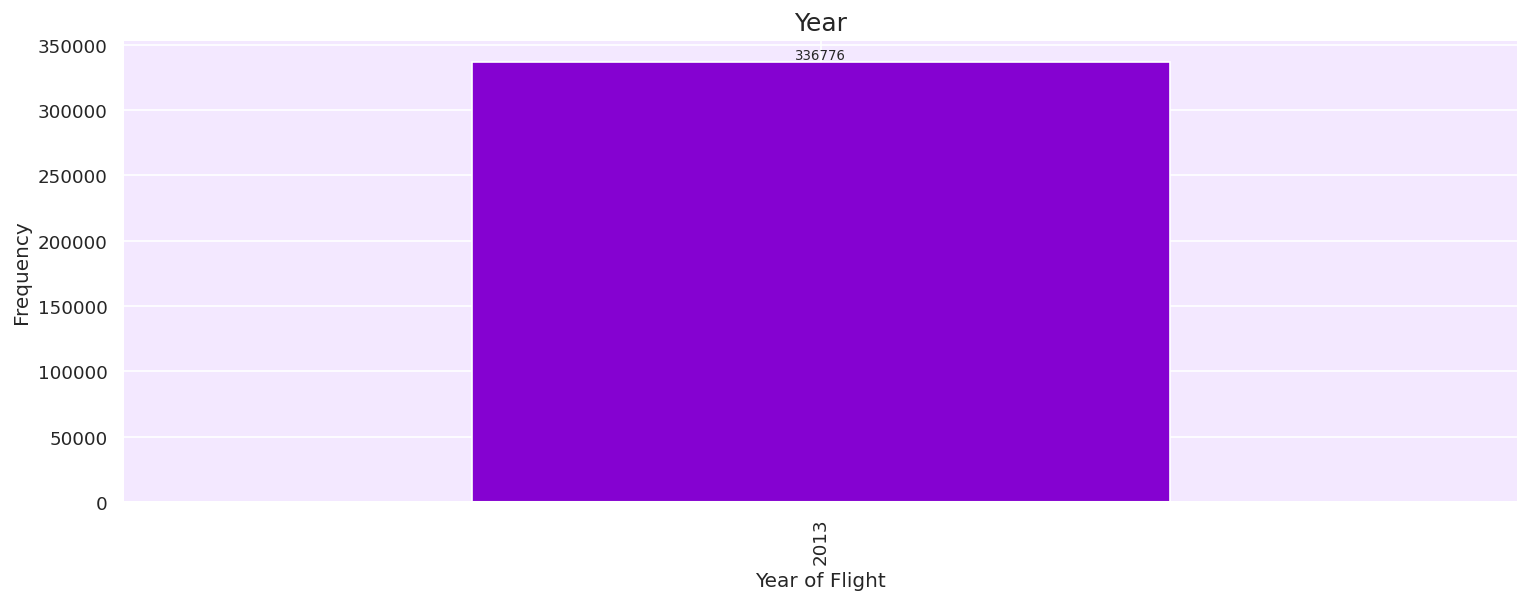

In [9]:
# The year in which the flight took place. The dataset includes flights from the year 2013.
plot_bar(df['year'], 'Year', 'Year of Flight')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The dataset contains flight data for only one year (__2013__), so the bar plot only has one bar.

### <b><span style='color:darkorange'>Step 4.1.2 |</span><span style='color:#8502d1'> month</span></b>

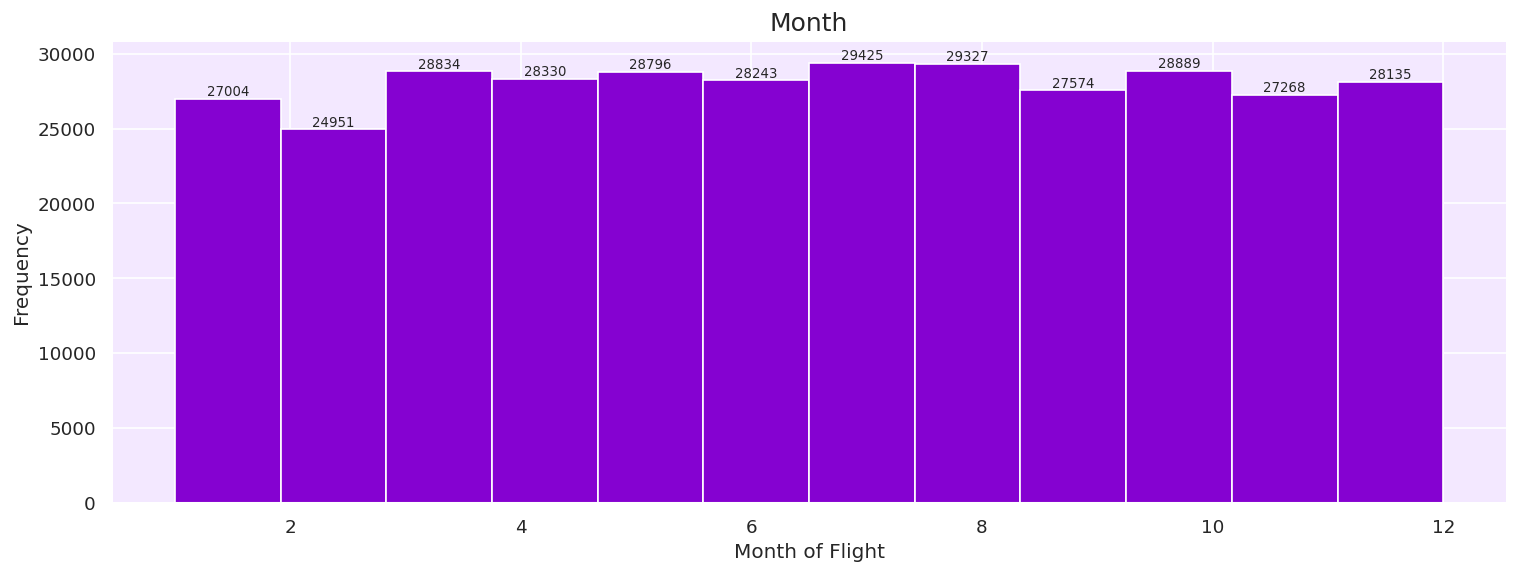

In [10]:
# The month of the year in which the flight occurred, represented by an integer ranging from 1 (January) to 12 (December).
plot_hist(df['month'], bins=12, title='Month', xlabel='Month of Flight')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The histogram shows that the distribution of flights across different months is approximately uniform, with __a slight decrease in February__, which is likely due to the fewer number of days in that month.

### <b><span style='color:darkorange'>Step 4.1.3 |</span><span style='color:#8502d1'> day</span></b>

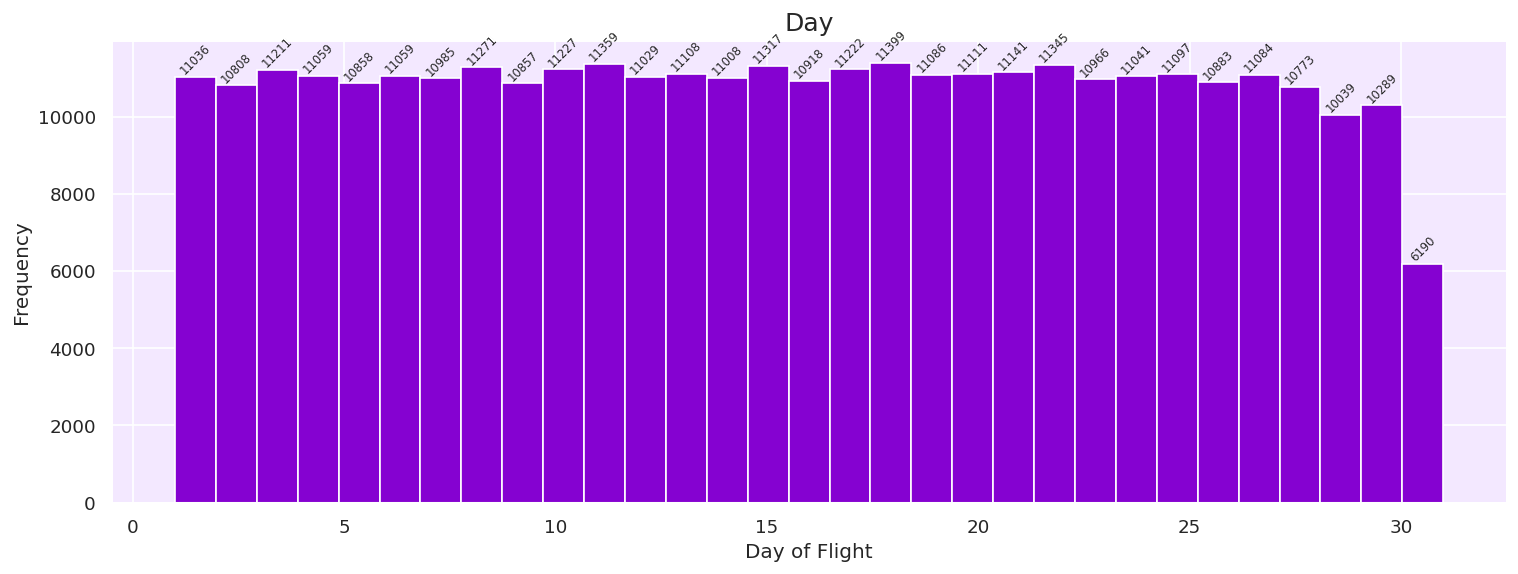

In [11]:
# The day of the month on which the flight took place, represented by an integer from 1 to 31.
plot_hist(df['day'], bins=31, title='Day', xlabel='Day of Flight', fontsize=7, rotation=45)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram reveals a mostly uniform distribution of flights across the days of the month, with slight decreases at the end of the month. These decreases are due to some months having fewer than 31 days.

### <b><span style='color:darkorange'>Step 4.1.4 |</span><span style='color:#8502d1'> dep_time</span></b>

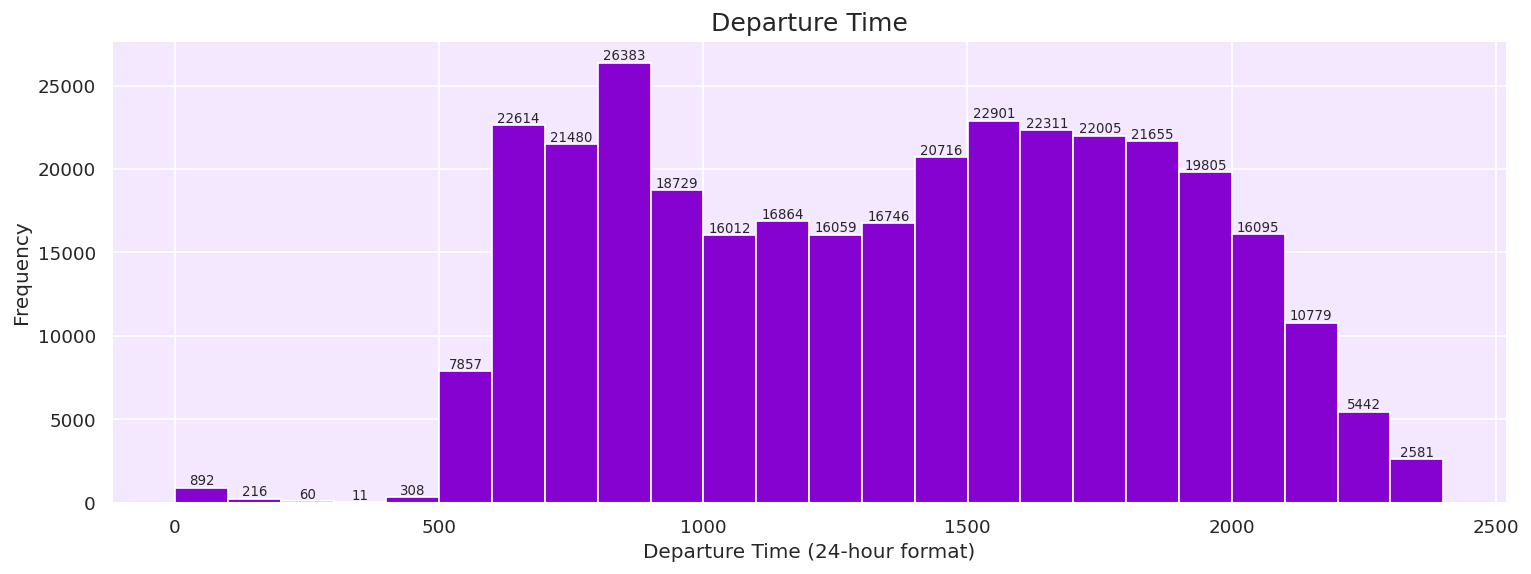

In [12]:
plot_hist(df['dep_time'].dropna(), bins=24, title='Departure Time', xlabel='Departure Time (24-hour format)')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The histogram shows __a bimodal distribution__, indicating two peak periods for flight departures. The first peak occurs in the morning around __06:00 hours__, and the second peak occurs in the evening around __18:00 hours__. There are fewer flights at night from 23:00 to 04:00 hours.

### <b><span style='color:darkorange'>Step 4.1.5 |</span><span style='color:#8502d1'> sched_dep_time</span></b>

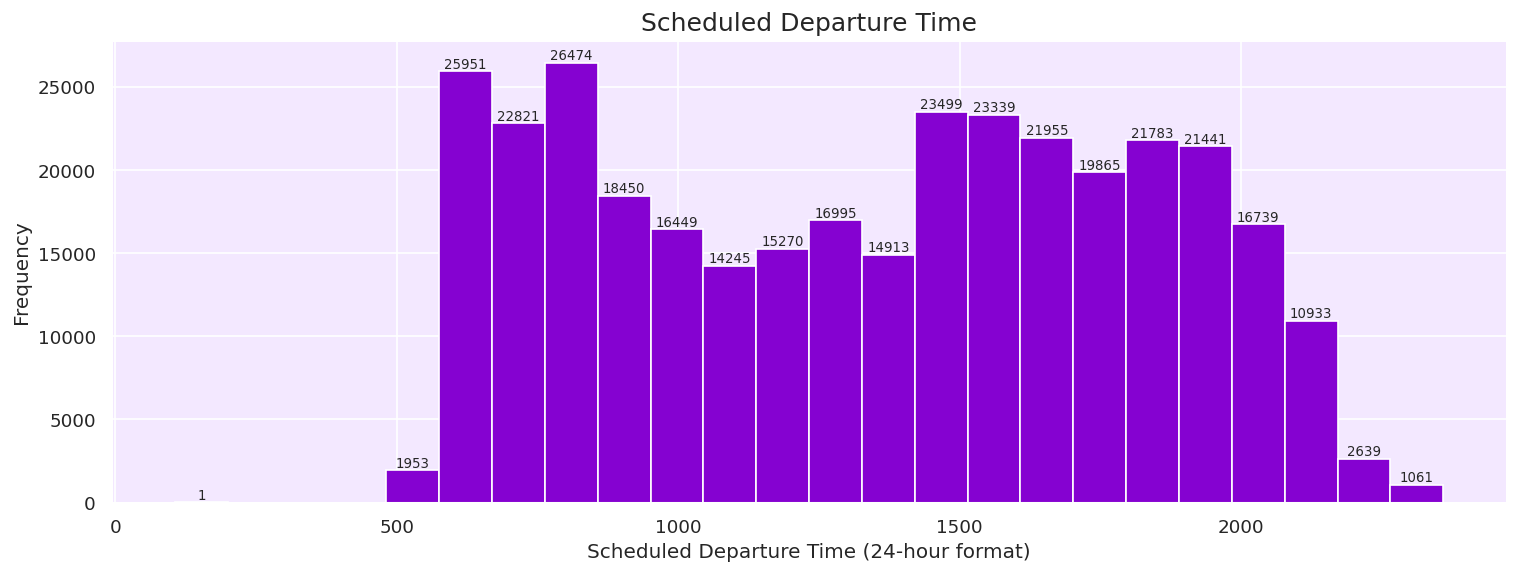

In [13]:
# The locally scheduled departure time of the flight, presented in a 24-hour format (hhmm).
plot_hist(df['sched_dep_time'], bins=24, title='Scheduled Departure Time', xlabel='Scheduled Departure Time (24-hour format)')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

This histogram is similar to the departure time histogram. It also shows two peak periods for scheduled flight departures, which are the same as the actual departure times.

### <b><span style='color:darkorange'>Step 4.1.6 |</span><span style='color:#8502d1'> dep_delay</span></b>

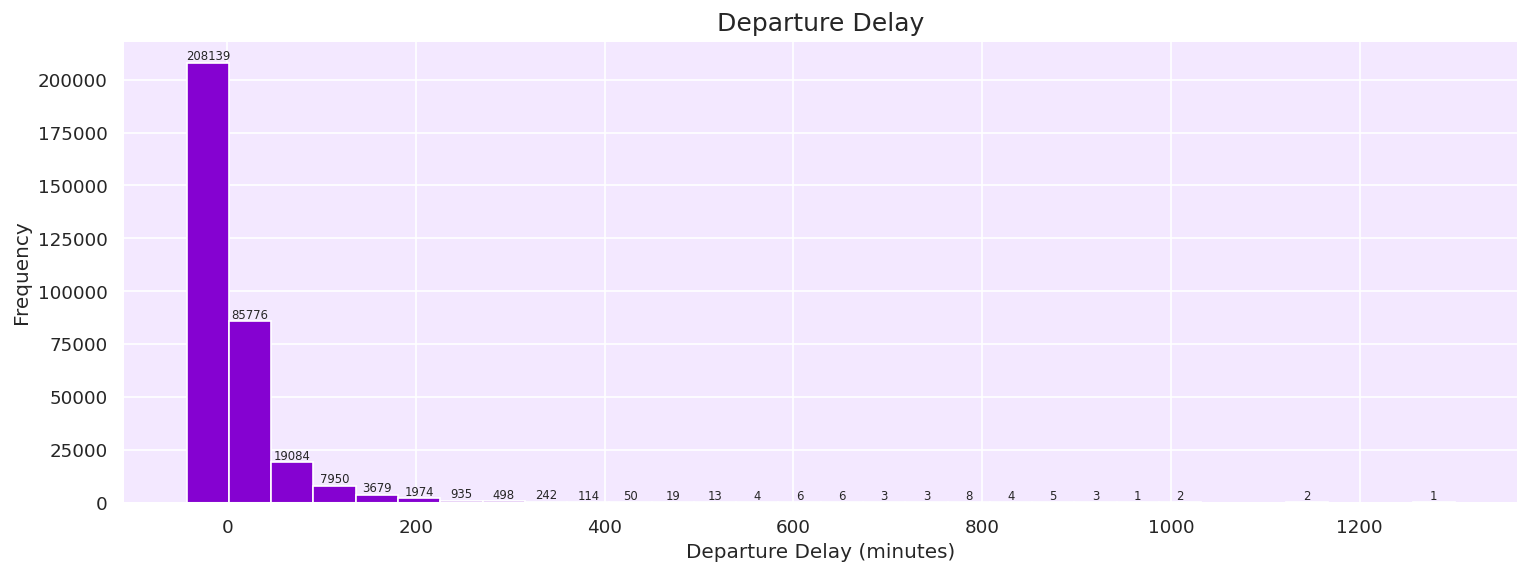

In [14]:
# The delay in flight departure, calculated as the difference (in minutes) between the actual and scheduled departure times. 
# Positive values indicate a delay, while negative values indicate an early departure.
plot_hist(df['dep_delay'].dropna(), bins=30, title='Departure Delay', xlabel='Departure Delay (minutes)', fontsize=7)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram indicates that most flights depart close to their scheduled departure time, as the peak of the distribution is around zero. However, there are also many flights with departure delays, shown by the long tail to the right of the distribution.

### <b><span style='color:darkorange'>Step 4.1.7 |</span><span style='color:#8502d1'> arr_time</span></b>

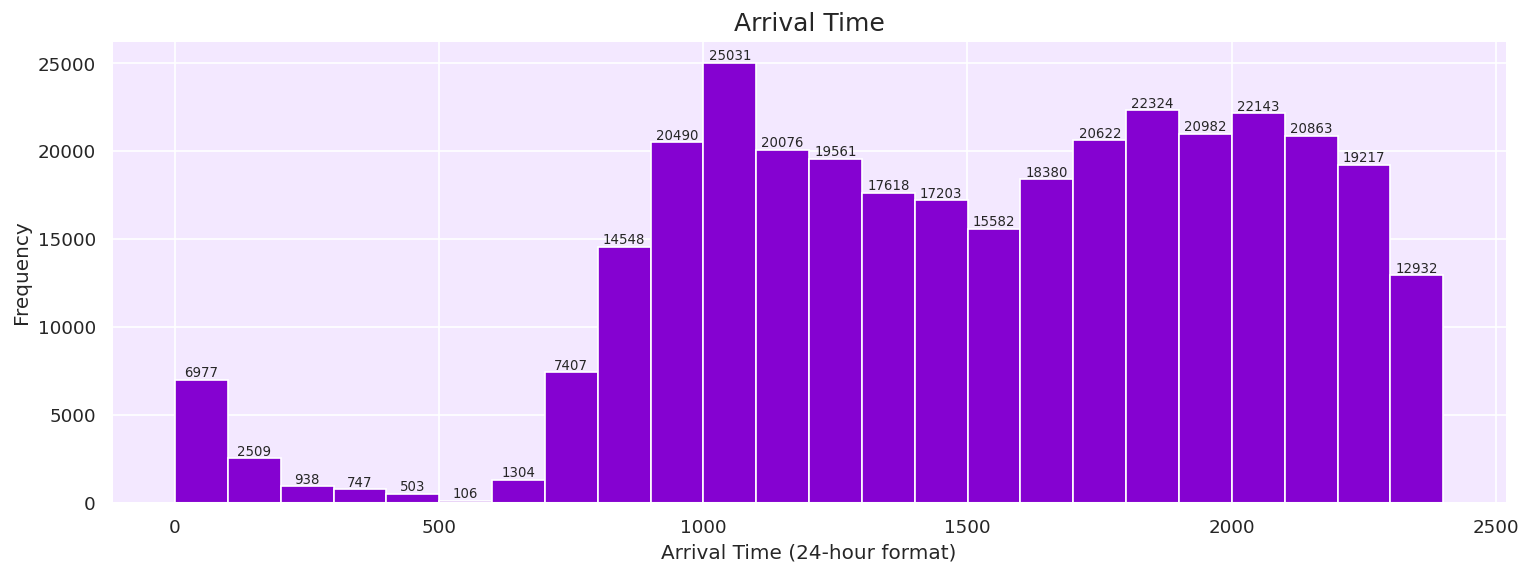

In [15]:
# The actual arrival time of the flight, represented in 24-hour format (hhmm).
plot_hist(df['arr_time'].dropna(), bins=24, title='Arrival Time', xlabel='Arrival Time (24-hour format)')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram shows a bimodal distribution, indicating two peak periods for flight arrivals. These are similar to the peak periods for flight departures.

### <b><span style='color:darkorange'>Step 4.1.8 |</span><span style='color:#8502d1'> sched_arr_time</span></b>

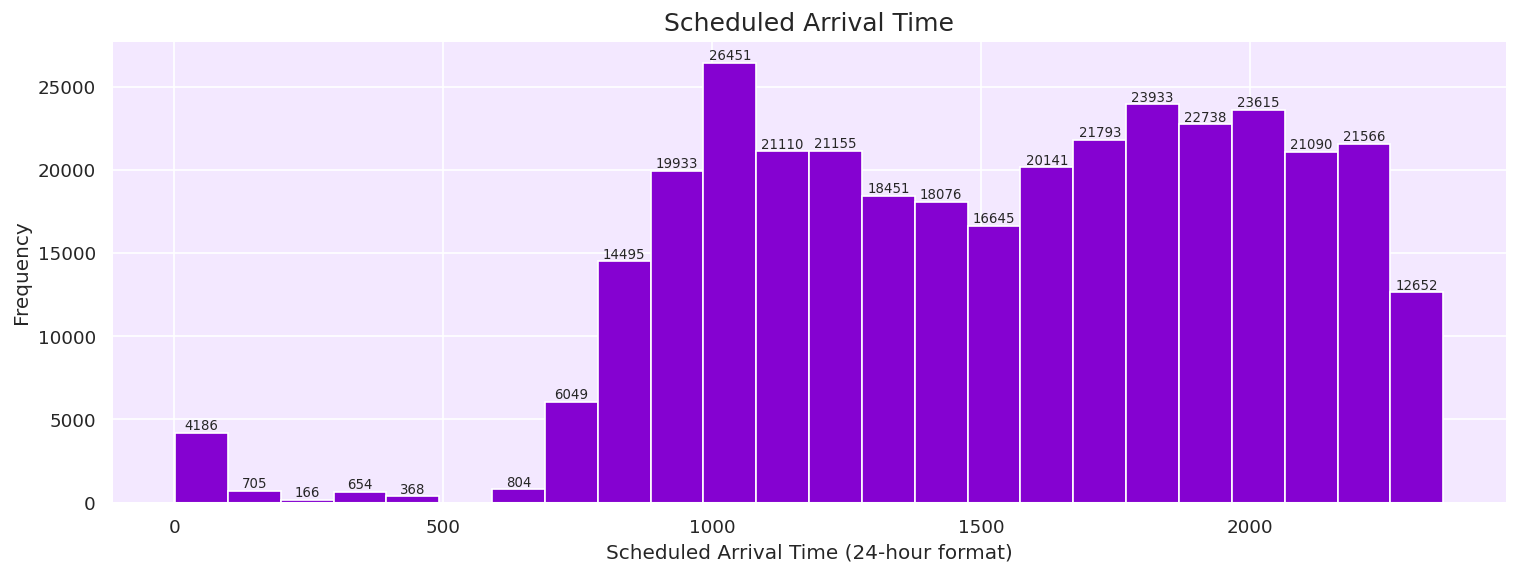

In [16]:
# The locally scheduled arrival time of the flight, presented in a 24-hour format (hhmm).
plot_hist(df['sched_arr_time'], bins=24, title='Scheduled Arrival Time', xlabel='Scheduled Arrival Time (24-hour format)')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
This histogram is similar to the arrival time histogram, indicating that the scheduling is consistent with the actual times.

### <b><span style='color:darkorange'>Step 4.1.9 |</span><span style='color:#8502d1'> arr_delay</span></b>

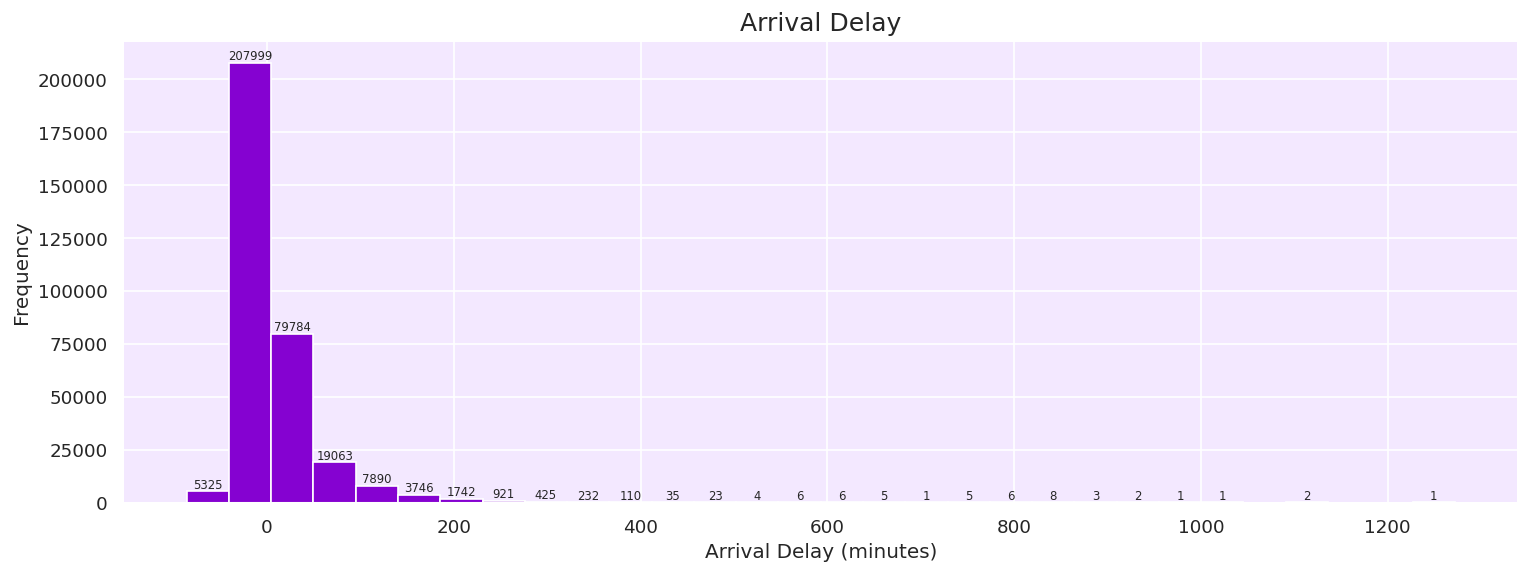

In [17]:
# The delay in flight arrival, calculated as the difference (in minutes) between the actual and scheduled arrival times. 
# Positive values indicate a delay, while negative values indicate an early arrival.
plot_hist(df['arr_delay'].dropna(), bins=30, title='Arrival Delay', xlabel='Arrival Delay (minutes)', fontsize=7)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram shows that most flights arrive close to their scheduled arrival time, as the peak of the distribution is around zero. However, there are also many flights with arrival delays, shown by the long tail to the right of the distribution.

### <b><span style='color:darkorange'>Step 4.1.10 |</span><span style='color:#8502d1'> carrier</span></b>

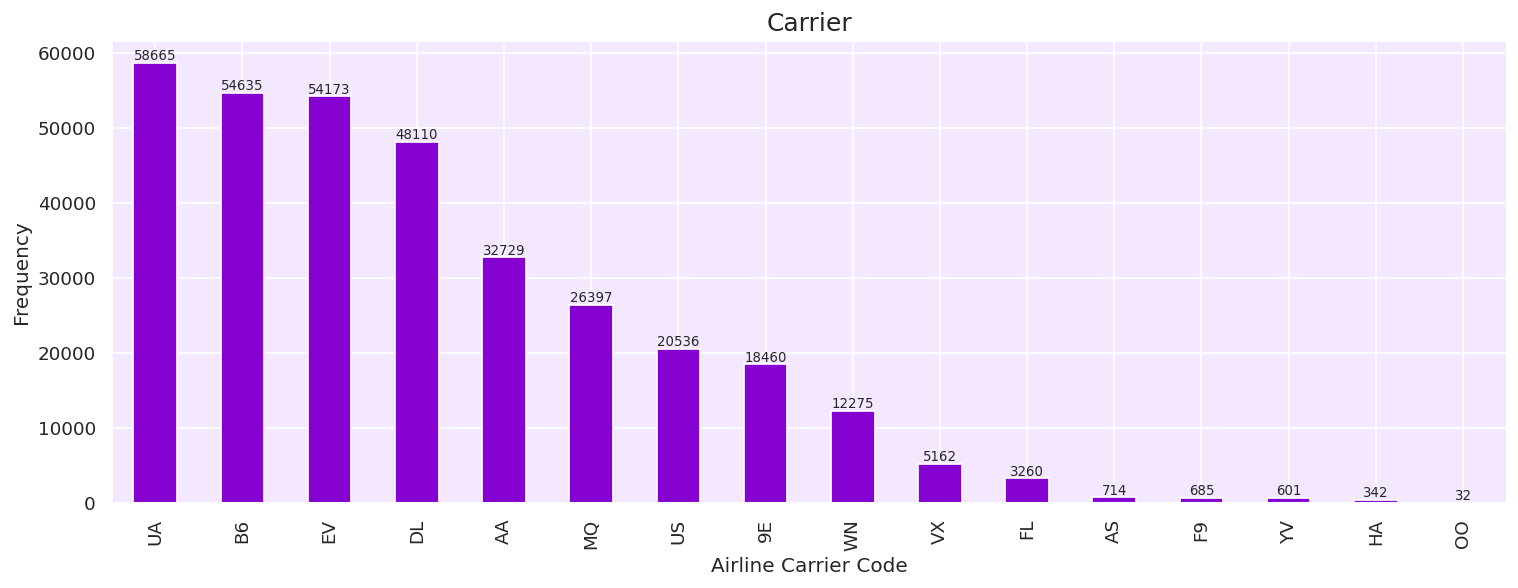

In [18]:
# A two-letter code representing the airline carrier responsible for the flight.
plot_bar(df['carrier'], 'Carrier', 'Airline Carrier Code')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The bar plot shows that the carriers with the codes __UA__, __B6__, __EV__, and __DL__ operate the most flights in this dataset.

### <b><span style='color:darkorange'>Step 4.1.11 |</span><span style='color:#8502d1'> origin</span></b>

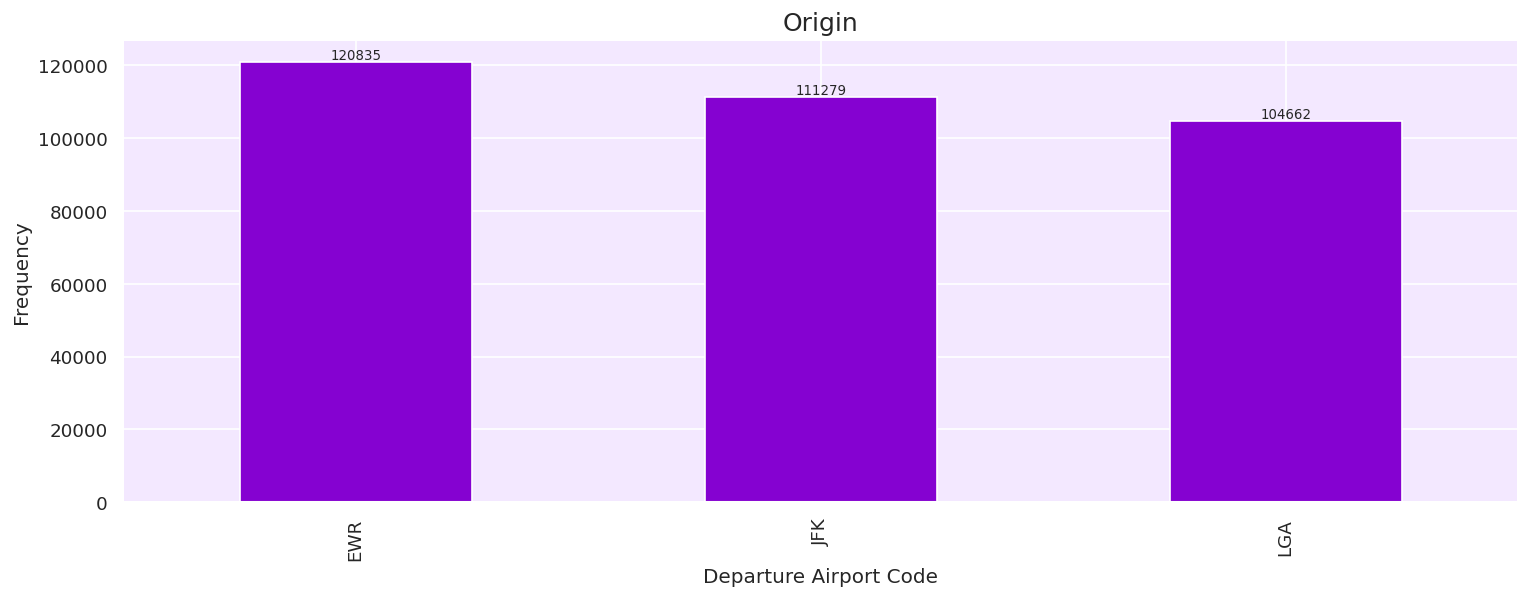

In [19]:
# A three-letter code signifying the airport from which the flight departed.
plot_bar(df['origin'], 'Origin', 'Departure Airport Code')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The bar plot reveals that the majority of flights in this dataset depart from the airport with the code __EWR__.

### <b><span style='color:darkorange'>Step 4.1.12 |</span><span style='color:#8502d1'> dest</span></b>

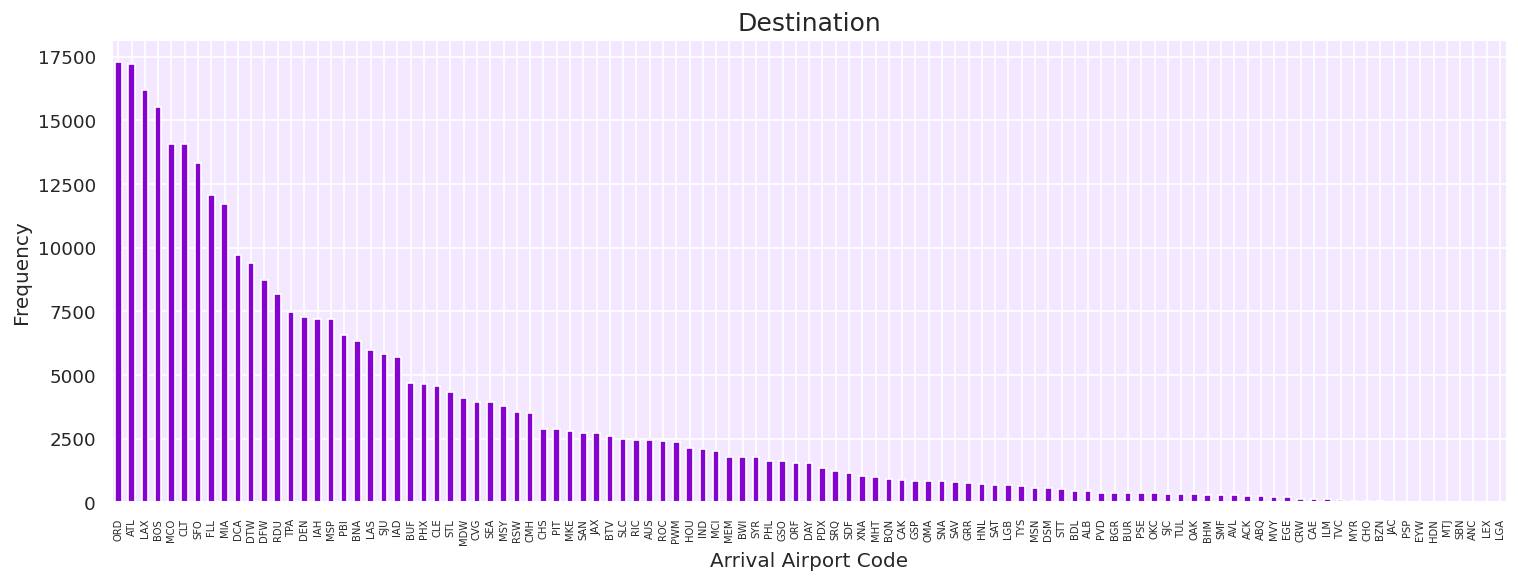

In [20]:
# A three-letter code representing the airport at which the flight arrived.
plt.figure(figsize=(15,5))
df['dest'].value_counts().plot(kind='bar', color=color)
plt.title('Destination', fontsize=15)
plt.xlabel('Arrival Airport Code', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(fontsize=6)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The bar plot shows that the most common destination airports are __ORD__, __ATL__, and __LAX__.

### <b><span style='color:darkorange'>Step 4.1.13 |</span><span style='color:#8502d1'> air_time</span></b>

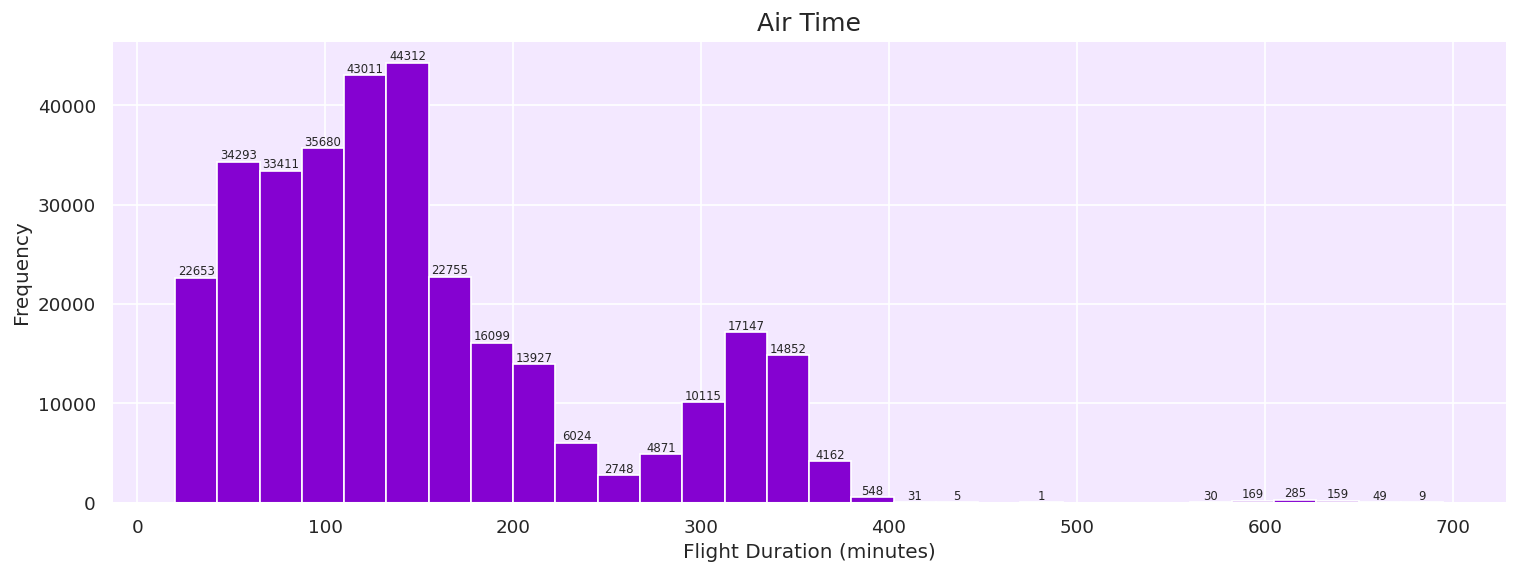

In [21]:
# The duration of the flight, measured in minutes.
plot_hist(df['air_time'].dropna(), bins=30, title='Air Time', xlabel='Flight Duration (minutes)', fontsize=7)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram shows that most flights have an air time of around 50 to 200 minutes, with a few flights having significantly longer air times.

### <b><span style='color:darkorange'>Step 4.1.14 |</span><span style='color:#8502d1'> distance</span></b>

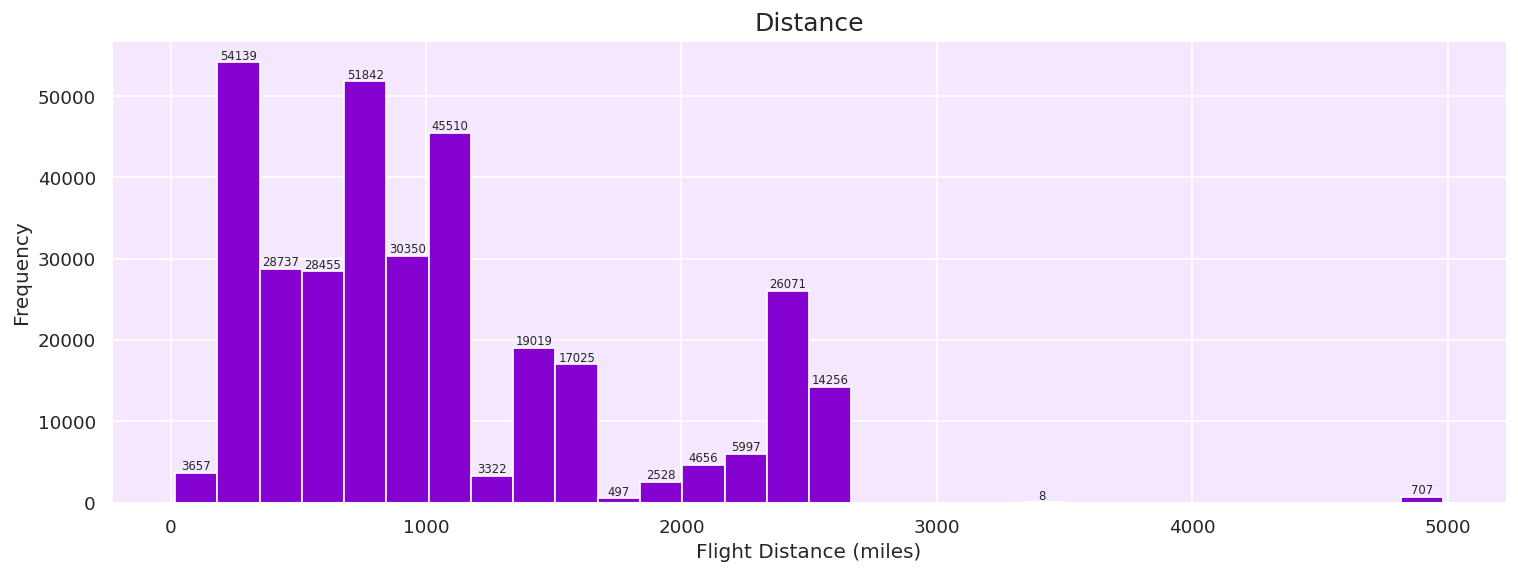

In [22]:
# The total distance (in miles) between the origin and destination airports.
plot_hist(df['distance'], bins=30, title='Distance', xlabel='Flight Distance (miles)', fontsize=7)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram shows that most flights travel a distance of around 500 to 1000 miles, with a few flights traveling significantly longer distances.    

### <b><span style='color:darkorange'>Step 4.1.15 |</span><span style='color:#8502d1'> hour</span></b>

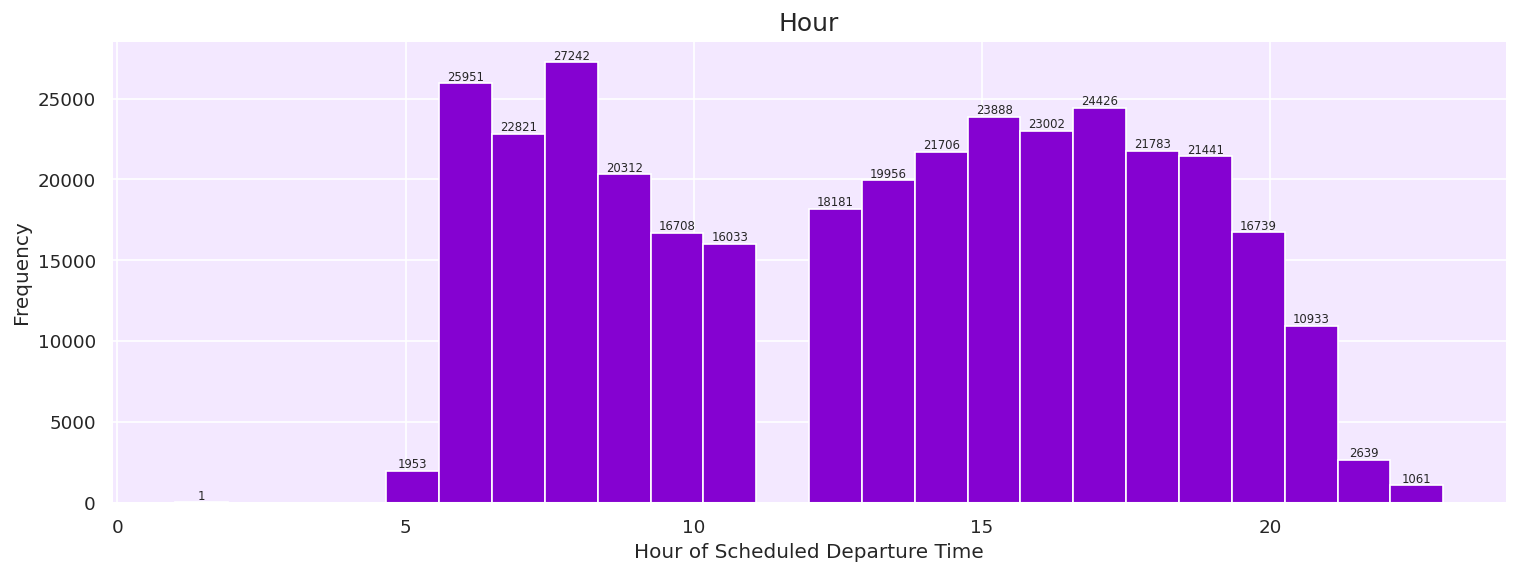

In [23]:
# The hour component of the scheduled departure time, expressed in local time.
plot_hist(df['hour'], bins=24, title='Hour', xlabel='Hour of Scheduled Departure Time', fontsize=7)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
he histogram reveals two peak periods for the hour component of the scheduled departure time, which correspond to the morning and evening peaks observed in the departure time histograms.    

### <b><span style='color:darkorange'>Step 4.1.16 |</span><span style='color:#8502d1'> minute</span></b>

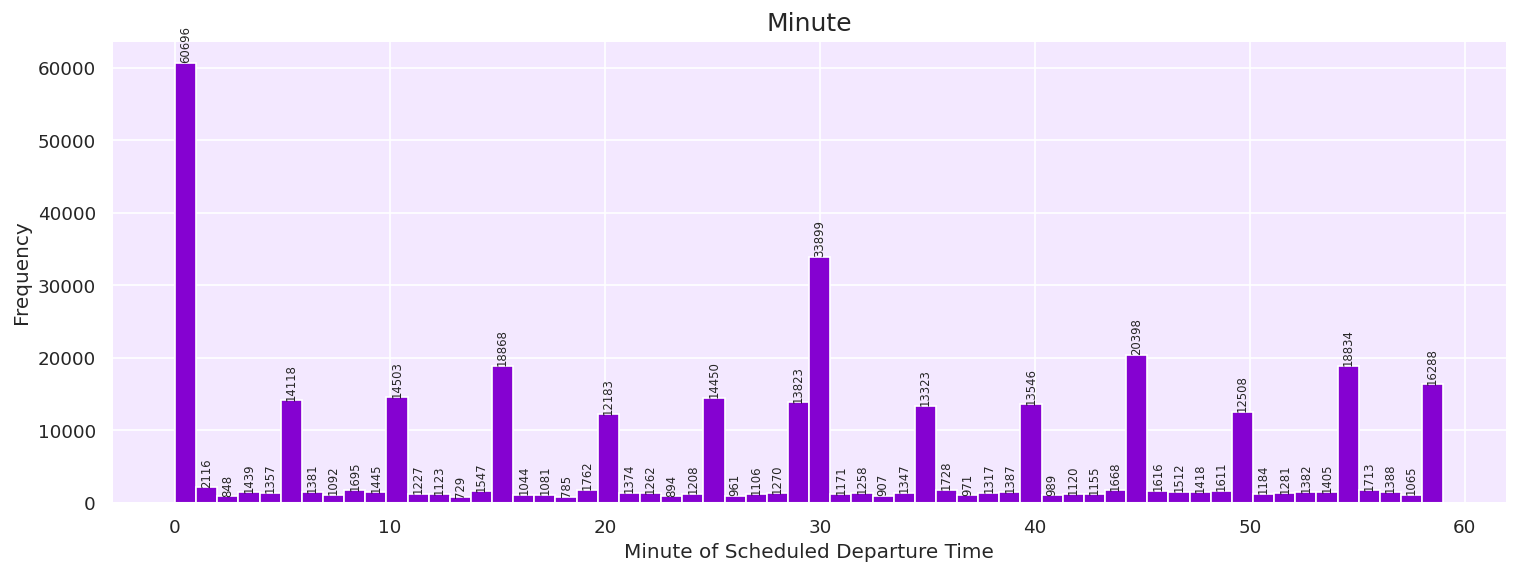

In [24]:
# The minute component of the scheduled departure time, expressed in local time.
plot_hist(df['minute'], bins=60, title='Minute', xlabel='Minute of Scheduled Departure Time', fontsize=7, rotation=90)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The histogram shows almost a uniform distribution for the minute component of the scheduled departure time, indicating that flights are evenly scheduled across all minutes of an hour.

### <b><span style='color:darkorange'>Step 4.1.17 |</span><span style='color:#8502d1'> name</span></b>

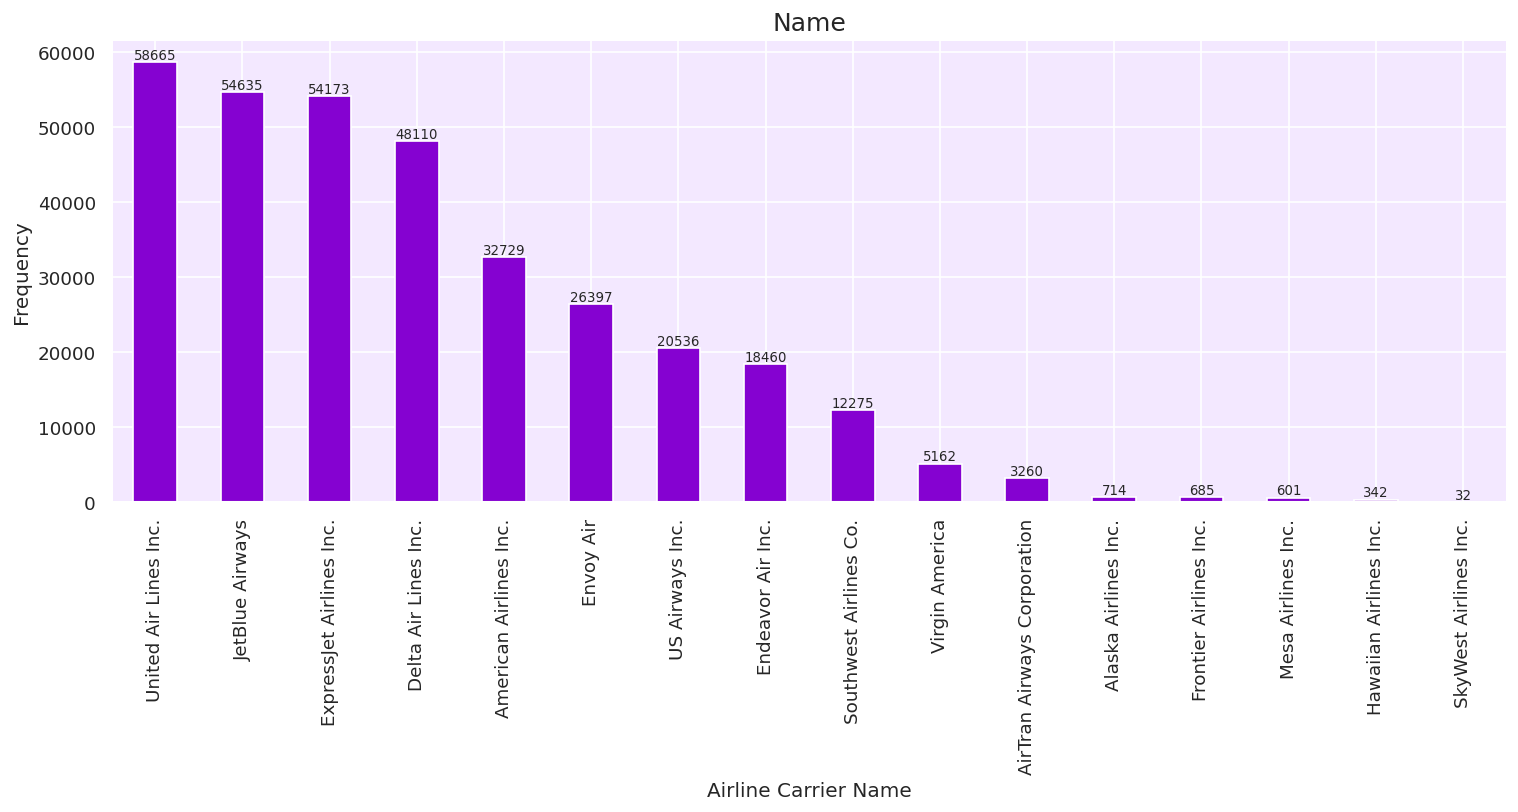

In [25]:
# The full name of the airline carrier responsible for the flight.
plot_bar(df['name'], 'Name', 'Airline Carrier Name')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The bar plot shows that __United Air Lines Inc.__, __JetBlue Airways__, and __ExpressJet Airlines Inc.__ are the airlines that operate the most flights in this dataset.

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Note:</font></h2>
    

* Since `id`, `flight`, `tailnum` are just __unique identifiers__ (__containing many unique values__) for each flight and does not provide any meaningful information, we skipped plotting them.
    
* The `time_hour` (scheduled departure time of the flight), represented in local time and formatted as __yyyy-mm-dd hh:mm:ss__. This column contains datetime information which is already represented by the `year`, `month`, `day`, `hour`, and `minute` columns, so we skipped plotting it as well.


____
<a id="bivariate"></a>
# <b><span style='color:darkorange'>Step 4.2 |</span><span style='color:#8502d1'> Bivariate Analysis</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
For our bivariate analysis, we'll consider the `arr_delay` column as the __target__. We can analyze the relationship between `arr_delay` and other columns. To do this, we can use __scatter plots__ for __numerical columns__ and __violin plots__ for __categorical columns__. We skip `id`, `flight`, `tailnum`, `time_hour` as they are identifiers or contain redundant information.

In [26]:
# Define color palette with different shades of color #8502d1 for boxplots
colors_box = sns.dark_palette("#8502d1", as_cmap=False)

# Define colormap with different shades of color #8502d1 for scatter plots
colors_scatter = sns.dark_palette("#8502d1", as_cmap=True)

# Define the function to plot scatter plots
def plot_scatter(x, y, title, xlabel, ylabel):
    plt.figure(figsize=(15,5))
    plt.scatter(x, y, c=y, cmap=colors_scatter, s=2)
    plt.title(title, fontsize=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.colorbar(label=ylabel)
    plt.show()

# Define the function to plot violin plots
def plot_violin(x, y, title, xlabel, ylabel, fontsize=8):
    plt.figure(figsize=(15,5))
    sns.violinplot(x=x, y=y, palette=colors_box)
    plt.title(title, fontsize=15)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.xticks(rotation=90, fontsize=fontsize)
    plt.show()

### <b><span style='color:darkorange'>Step 4.2.1 |</span><span style='color:#8502d1'> Year vs Arrival Delay</span></b>

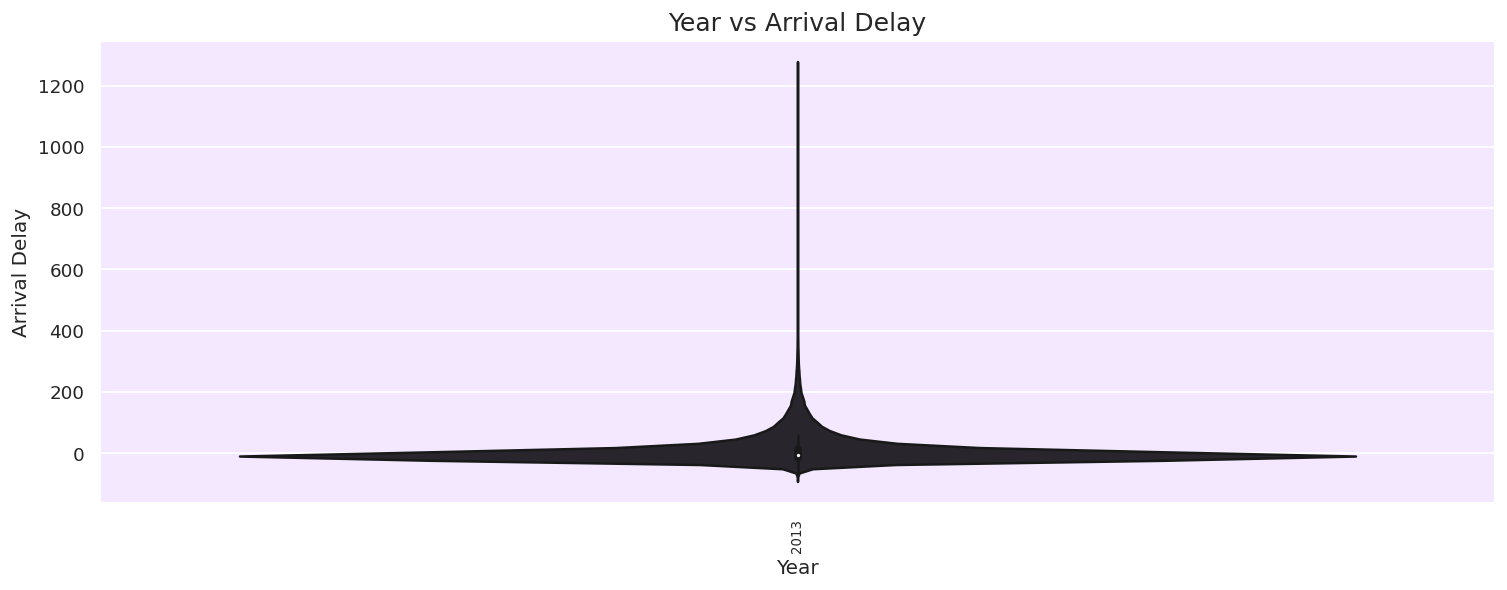

In [27]:
# year vs arr_delay
plot_violin(df['year'], df['arr_delay'], 'Year vs Arrival Delay', 'Year', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The violin plot does not provide much information as the dataset contains flights from only one year.

### <b><span style='color:darkorange'>Step 4.2.2 |</span><span style='color:#8502d1'> Month vs Arrival Delay</span></b>

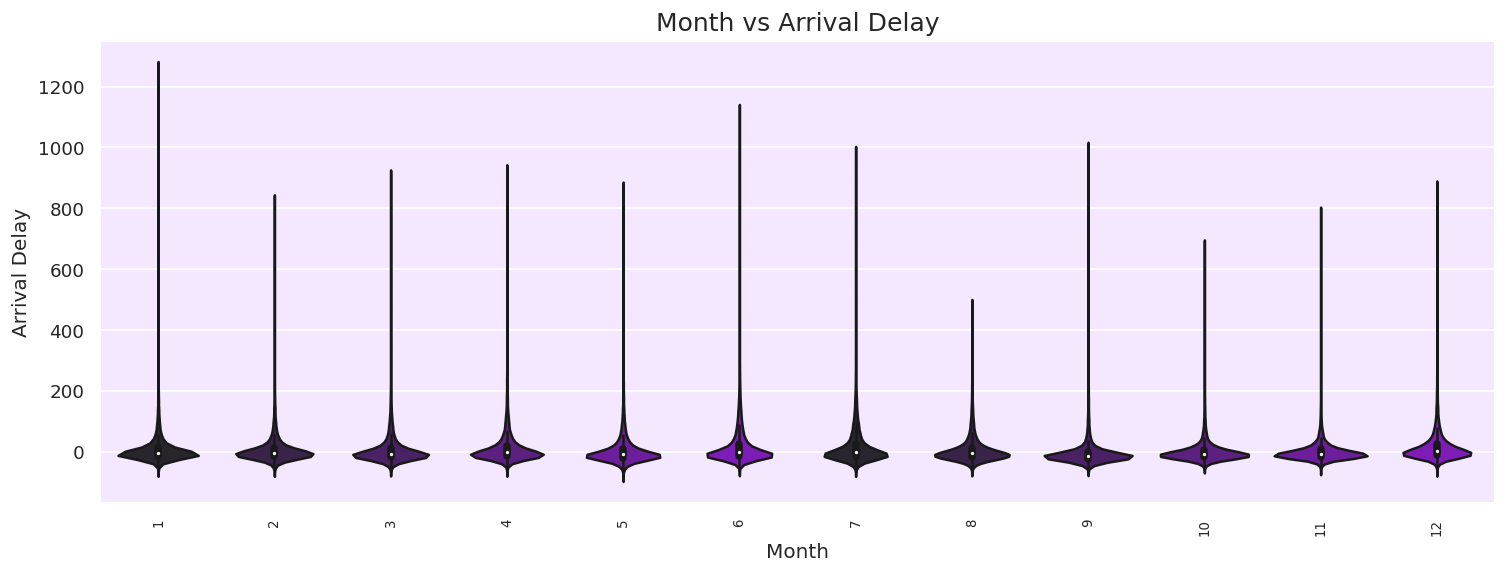

In [28]:
# month vs arr_delay
plot_violin(df['month'], df['arr_delay'], 'Month vs Arrival Delay', 'Month', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The violin plot shows that the distribution of arrival delays varies by month. Some months (like __June__, __July__, and __December__) have wider distributions, indicating a higher variability in arrival delays.

### <b><span style='color:darkorange'>Step 4.2.3 |</span><span style='color:#8502d1'> Day vs Arrival Delay</span></b>

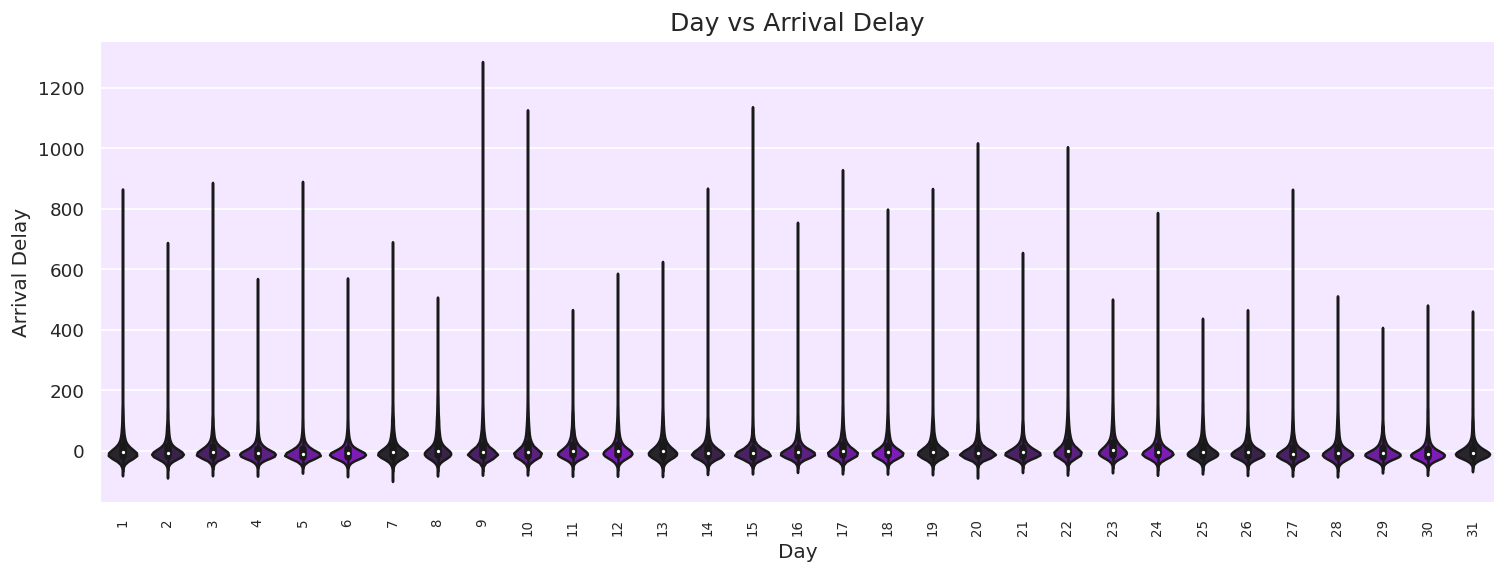

In [29]:
# day vs arr_delay
plot_violin(df['day'], df['arr_delay'], 'Day vs Arrival Delay', 'Day', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The violin plot indicates that the day of the month does not have a significant impact on the distribution of arrival delays.

### <b><span style='color:darkorange'>Step 4.2.4 |</span><span style='color:#8502d1'> Departure Time vs Arrival Delay</span></b>

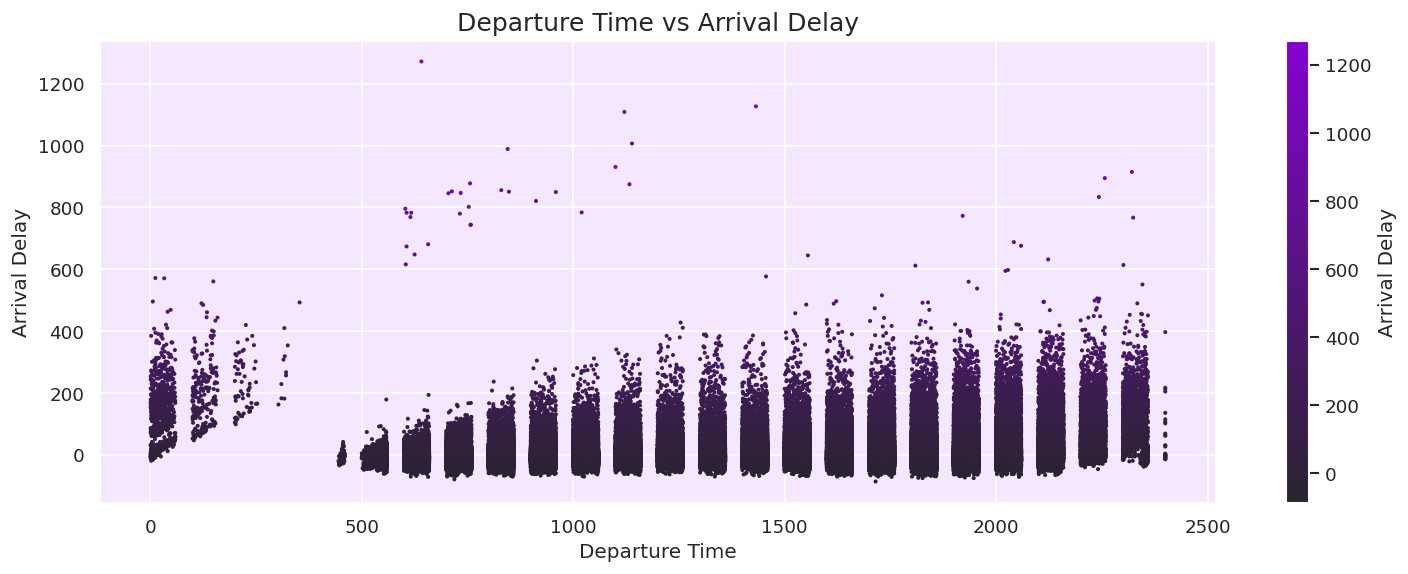

In [30]:
# dep_time vs arr_delay
plot_scatter(df['dep_time'], df['arr_delay'], 'Departure Time vs Arrival Delay', 'Departure Time', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The scatter plot shows a slight trend indicating that flights departing later in the day tend to have more delays.

### <b><span style='color:darkorange'>Step 4.2.5 |</span><span style='color:#8502d1'> Scheduled Departure Time vs Arrival Delay</span></b>

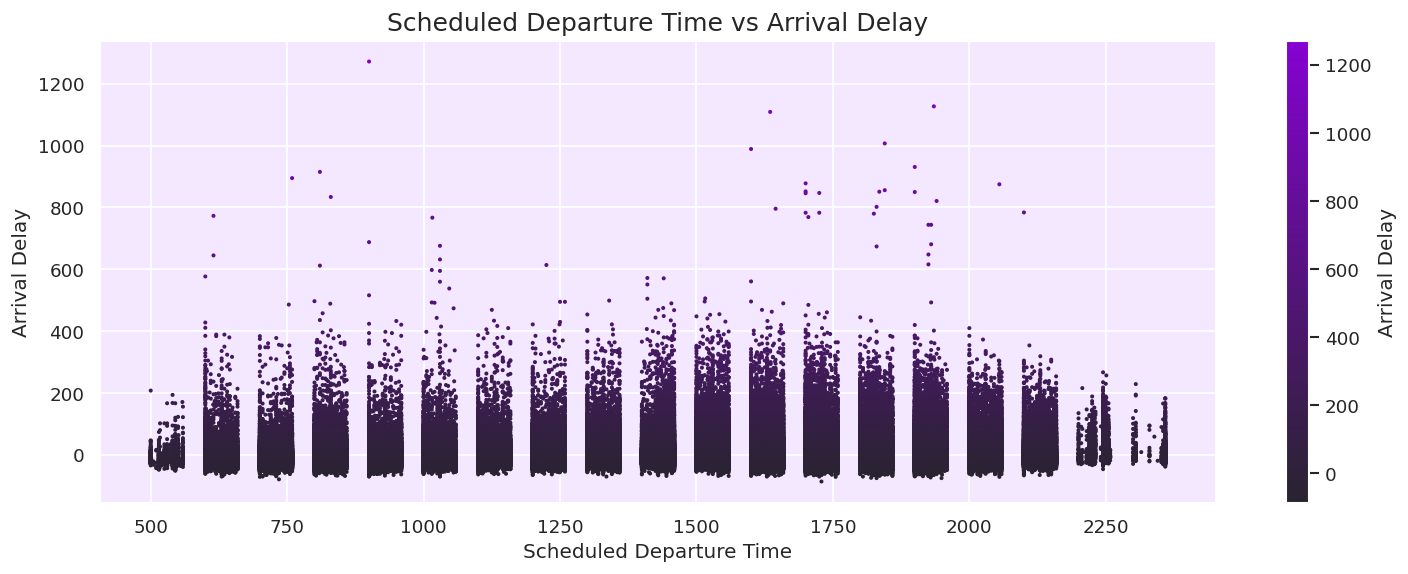

In [31]:
# sched_dep_time vs arr_delay
plot_scatter(df['sched_dep_time'], df['arr_delay'], 'Scheduled Departure Time vs Arrival Delay', 'Scheduled Departure Time', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
This plot shows a similar pattern to the previous one, indicating that flights scheduled to depart later in the day tend to have more delays.

### <b><span style='color:darkorange'>Step 4.2.6 |</span><span style='color:#8502d1'> Departure Delay vs Arrival Delay</span></b>

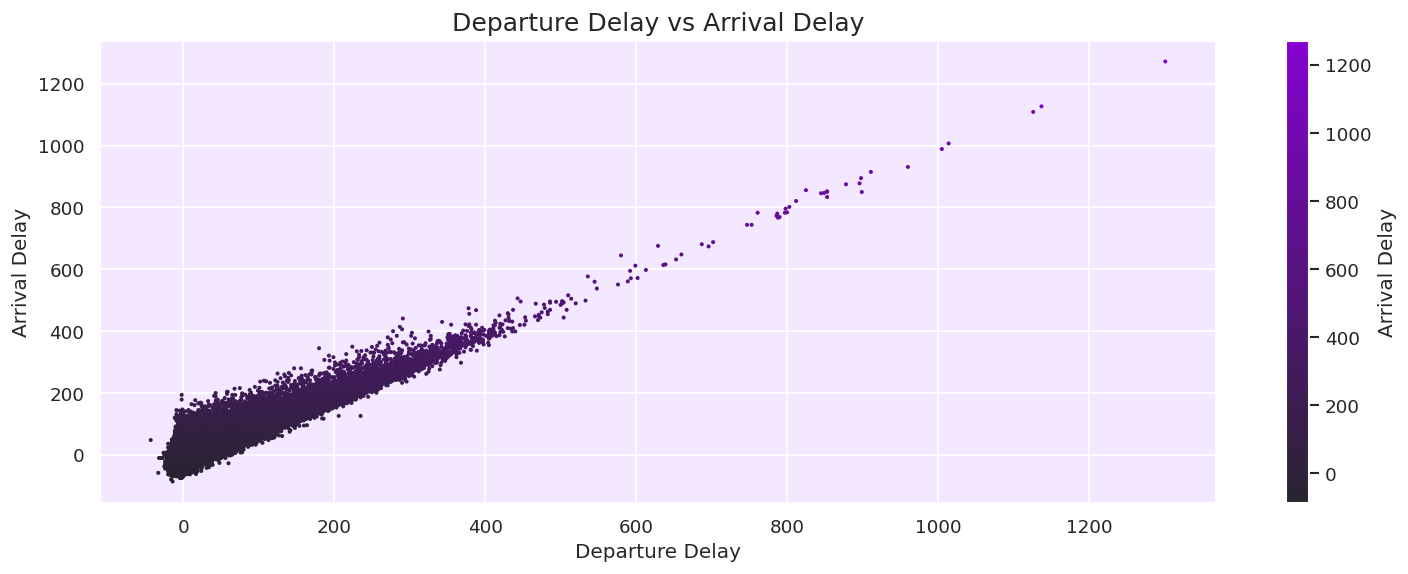

In [32]:
# dep_delay vs arr_delay
plot_scatter(df['dep_delay'], df['arr_delay'], 'Departure Delay vs Arrival Delay', 'Departure Delay', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

As expected, there is a strong positive correlation between departure delay and arrival delay.

### <b><span style='color:darkorange'>Step 4.2.7 |</span><span style='color:#8502d1'> Arrival Time vs Arrival Delay</span></b>

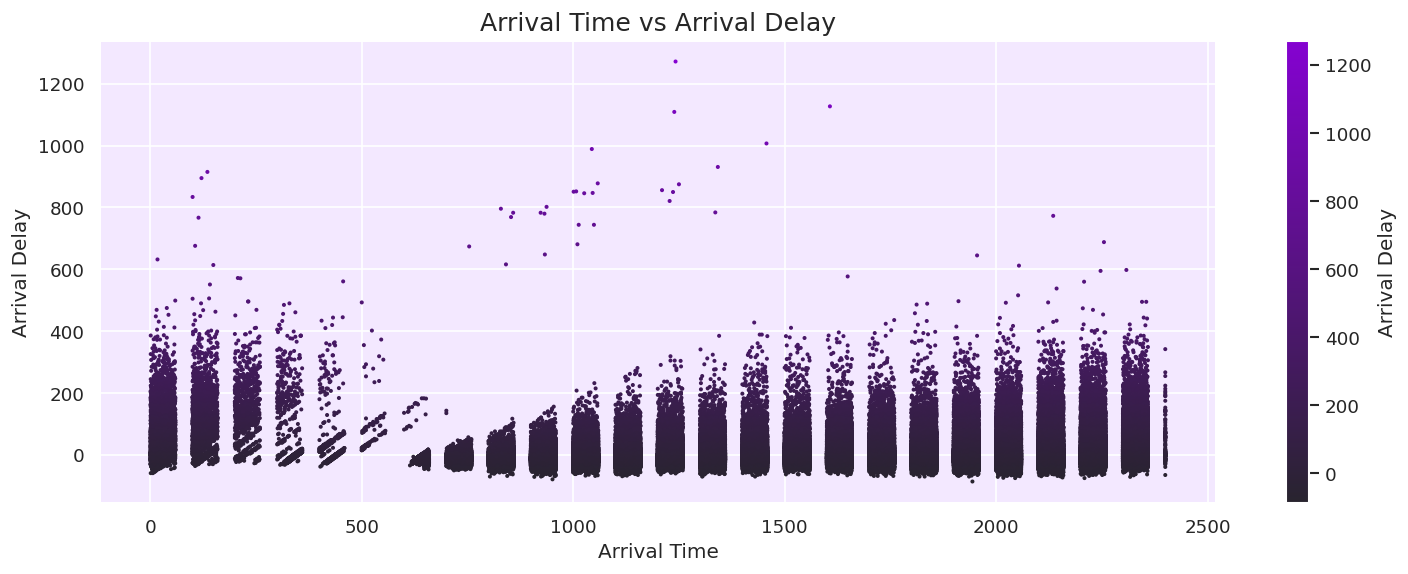

In [33]:
# arr_time vs arr_delay
plot_scatter(df['arr_time'], df['arr_delay'], 'Arrival Time vs Arrival Delay', 'Arrival Time', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The scatter plot shows that flights arriving later in the day tend to have more delays, which is consistent with the departure time observations.

### <b><span style='color:darkorange'>Step 4.2.8 |</span><span style='color:#8502d1'> Scheduled Arrival Time vs Arrival Delay</span></b>

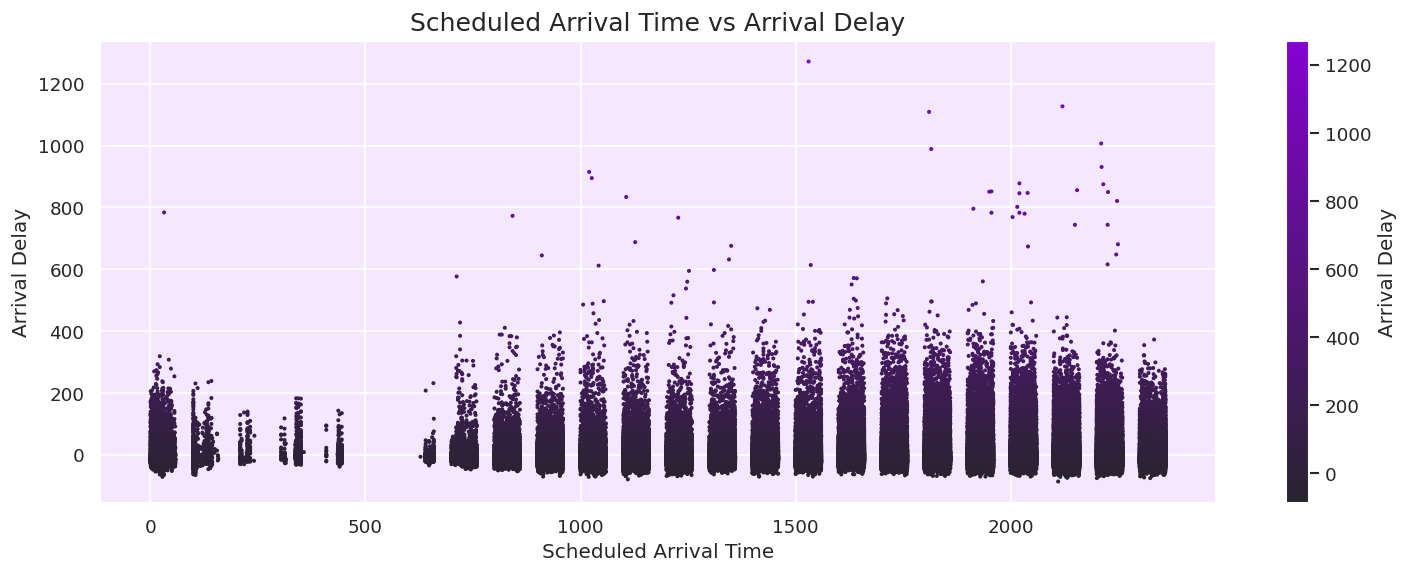

In [34]:
# sched_arr_time vs arr_delay
plot_scatter(df['sched_arr_time'], df['arr_delay'], 'Scheduled Arrival Time vs Arrival Delay', 'Scheduled Arrival Time', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

This plot also shows that flights scheduled to arrive later in the day tend to have more delays.

### <b><span style='color:darkorange'>Step 4.2.9 |</span><span style='color:#8502d1'> Carrier vs Arrival Delay</span></b>

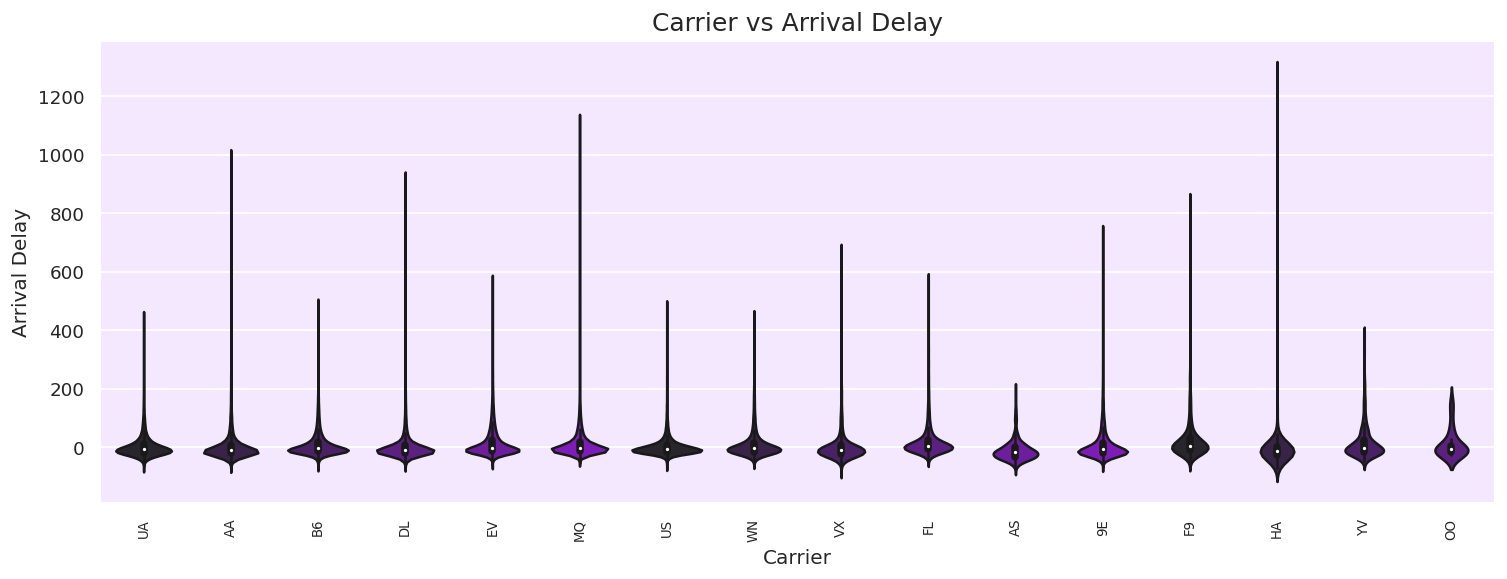

In [35]:
# carrier vs arr_delay
plot_violin(df['carrier'], df['arr_delay'], 'Carrier vs Arrival Delay', 'Carrier', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The violin plot shows that different carriers have different distributions of arrival delays. Some carriers tend to have more severe delays, while others have milder delays.

### <b><span style='color:darkorange'>Step 4.2.10 |</span><span style='color:#8502d1'> Origin vs Arrival Delay</span></b>

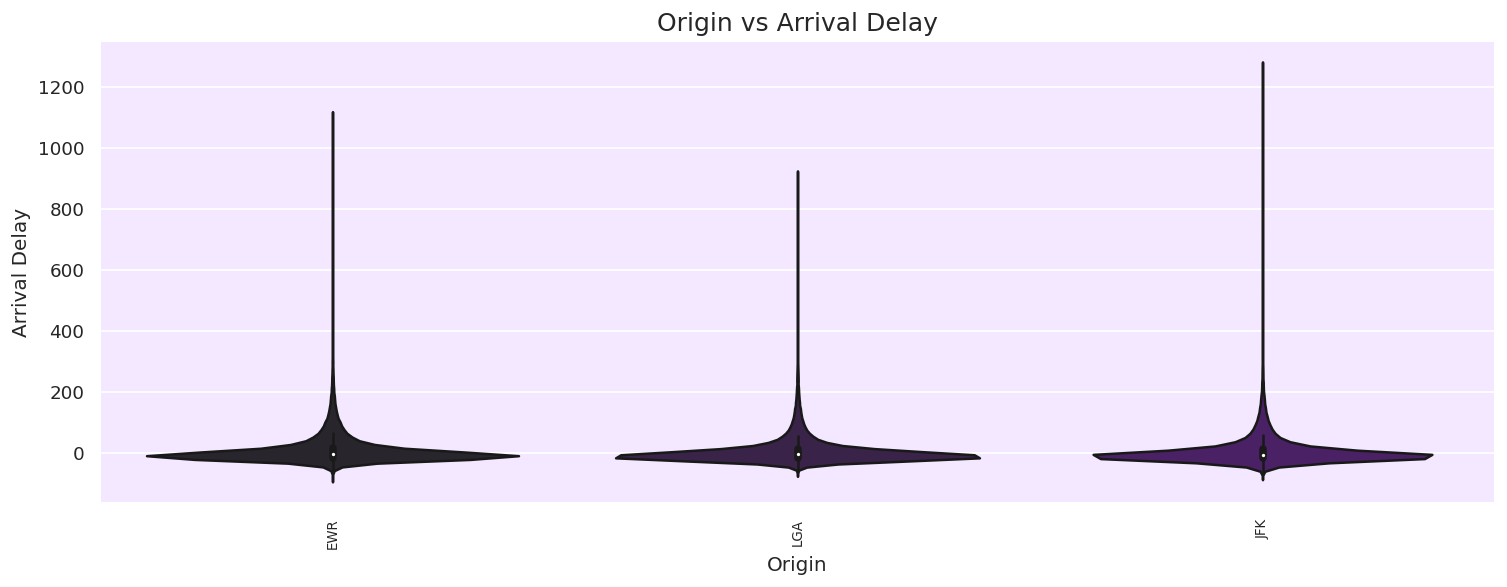

In [36]:
# origin vs arr_delay
plot_violin(df['origin'], df['arr_delay'], 'Origin vs Arrival Delay', 'Origin', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The violin plot shows that flights from different origins have different distributions of arrival delays. Some airports tend to have flights with more severe delays, while others have flights with milder delays.

### <b><span style='color:darkorange'>Step 4.2.11 |</span><span style='color:#8502d1'> Destination vs Arrival Delay</span></b>

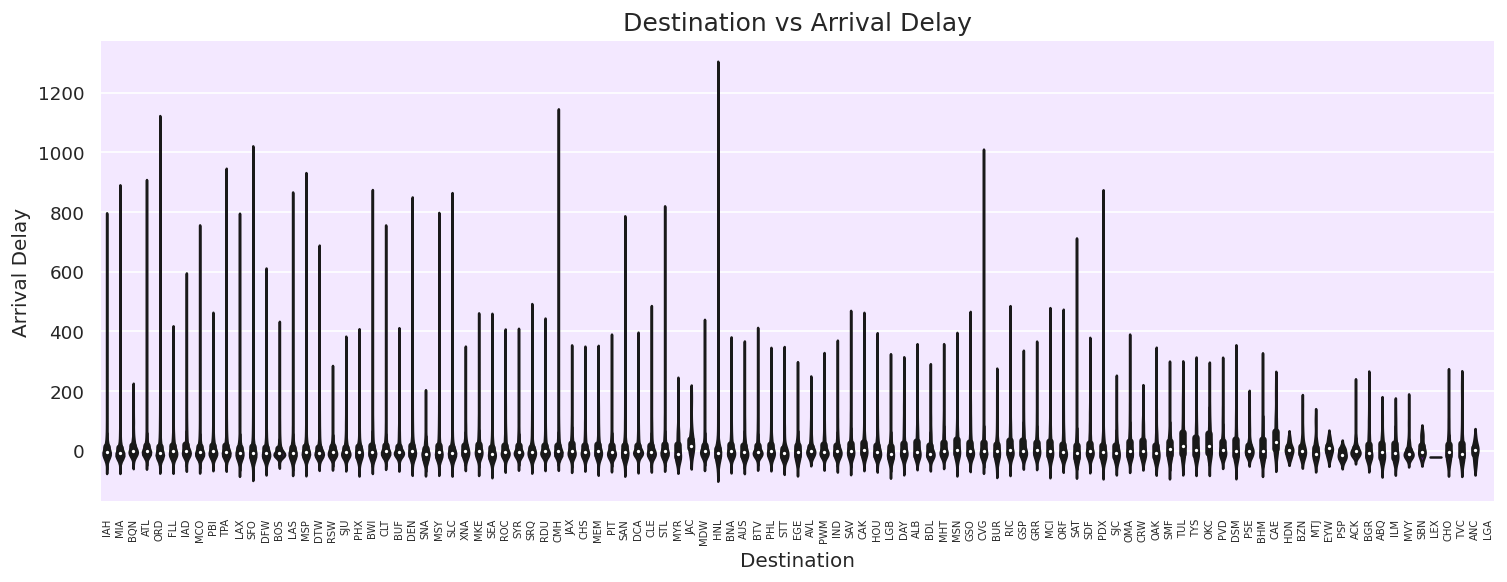

In [37]:
# dest vs arr_delay
plot_violin(df['dest'], df['arr_delay'], 'Destination vs Arrival Delay', 'Destination', 'Arrival Delay', fontsize=6)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The violin plot shows that flights going to different destinations have different distributions of arrival delays. Some destination airports tend to receive flights with more severe delays, while others receive flights with milder delays.

### <b><span style='color:darkorange'>Step 4.2.12 |</span><span style='color:#8502d1'> Air Time vs Arrival Delay</span></b>

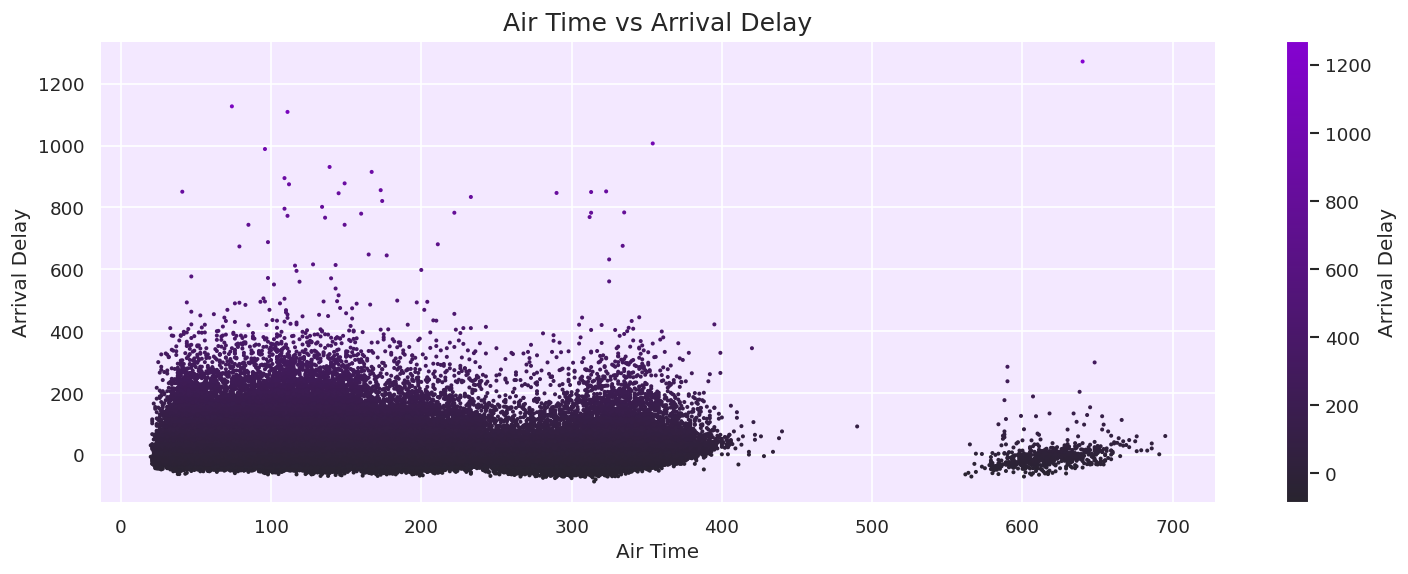

In [38]:
# air_time vs arr_delay
plot_scatter(df['air_time'], df['arr_delay'], 'Air Time vs Arrival Delay', 'Air Time', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

The scatter plot does not show a clear trend, suggesting that the duration of the flight (`air_time`) does not have a significant impact on the arrival delay.

### <b><span style='color:darkorange'>Step 4.2.13 |</span><span style='color:#8502d1'> Distance vs Arrival Delay</span></b>

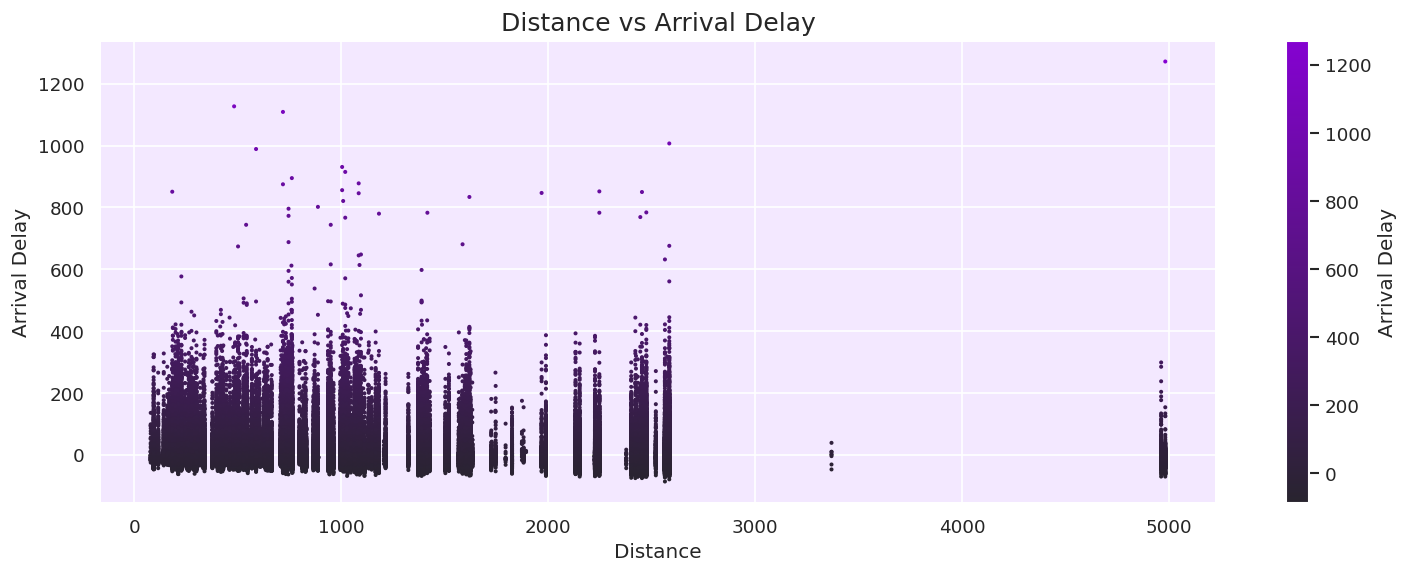

In [39]:
# distance vs arr_delay
plot_scatter(df['distance'], df['arr_delay'], 'Distance vs Arrival Delay', 'Distance', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

This plot also does not show a clear trend, indicating that the distance of the flight does not have a significant impact on the arrival delay.

### <b><span style='color:darkorange'>Step 4.2.14 |</span><span style='color:#8502d1'> Hour vs Arrival Delay</span></b>

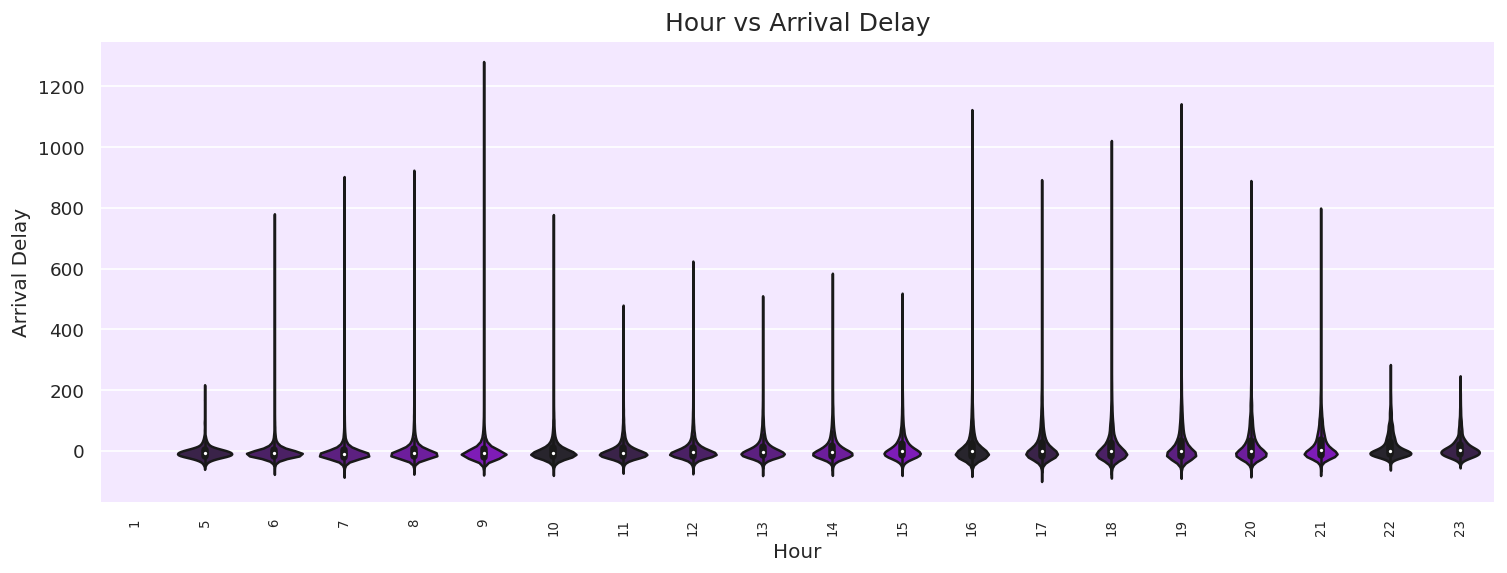

In [40]:
# hour vs arr_delay
plot_violin(df['hour'], df['arr_delay'], 'Hour vs Arrival Delay', 'Hour', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The violin plot shows that flights departing at different hours of the day have different distributions of arrival delays. Flights departing later in the day tend to have a higher variability in arrival delays.

### <b><span style='color:darkorange'>Step 4.2.15 |</span><span style='color:#8502d1'> Minute vs Arrival Delay</span></b>

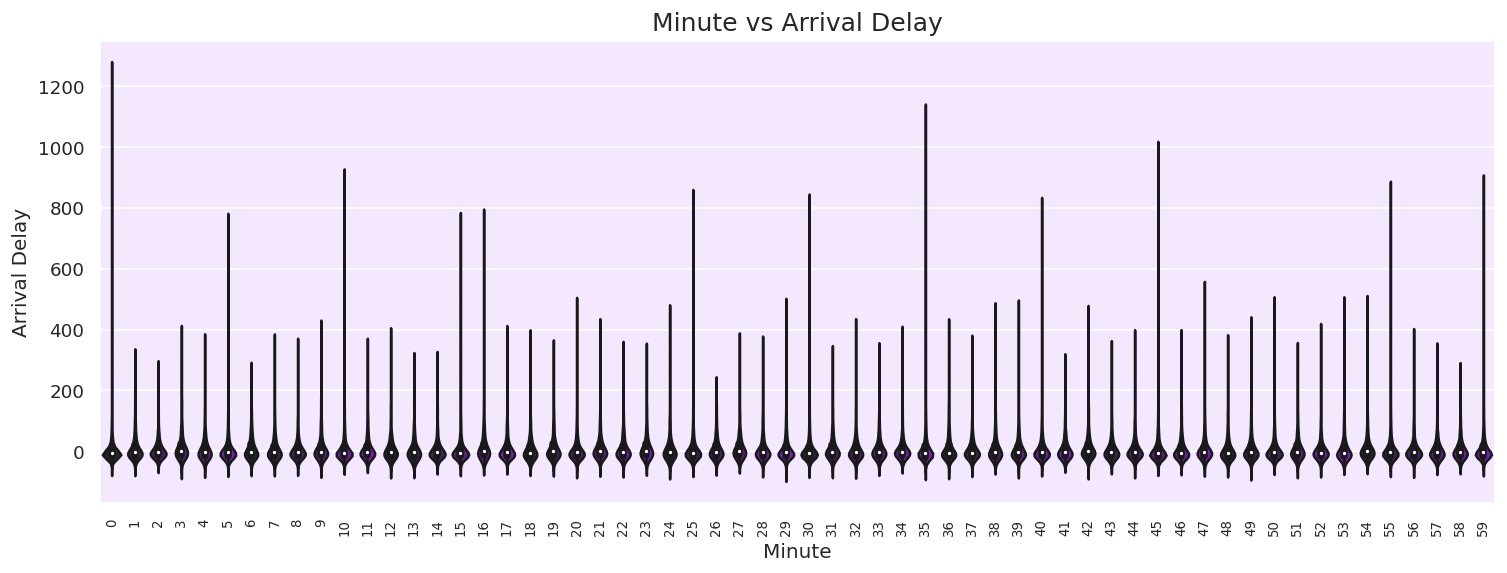

In [41]:
# minute vs arr_delay
plot_violin(df['minute'], df['arr_delay'], 'Minute vs Arrival Delay', 'Minute', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The violin plot suggests that the minute of the hour of the departure time does not have a significant impact on the distribution of arrival delays.

### <b><span style='color:darkorange'>Step 4.2.16 |</span><span style='color:#8502d1'> Name vs Arrival Delay</span></b>

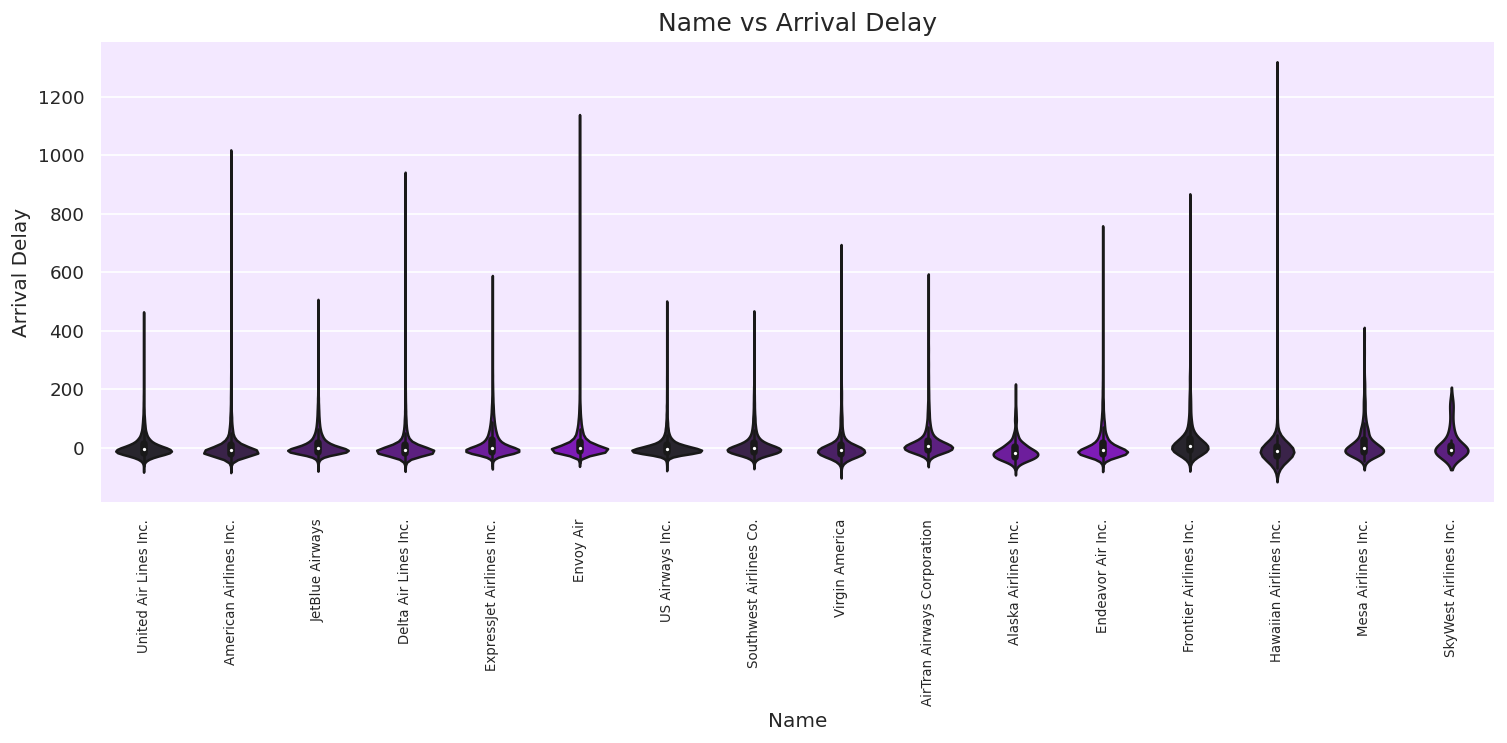

In [42]:
# name vs arr_delay
plot_violin(df['name'], df['arr_delay'], 'Name vs Arrival Delay', 'Name', 'Arrival Delay')

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
This violin plot shows that different airlines (represented by their names) have different distributions of arrival delays. Some airlines tend to have more severe delays, while others have milder delays.

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Conclusion:</font></h2>

Based on the bivariate analysis, the features that have a __noticeable impact on arrival delay__ are:

- Month
- Departure Time and Scheduled Departure Time
- Departure Delay
- Arrival Time and Scheduled Arrival Time
- Carrier
- Origin
- Destination
- Hour

On the other hand, the following features __do not__ seem to significantly __influence arrival delay__:

- Day
- Air Time
- Distance
- Minute

____
<a id="multivariate"></a>

# <b><span style='color:darkorange'>Step 4.3 |</span><span style='color:#8502d1'> Multivariate Analysis</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

A multivariate analysis will allow us to understand the interactions between different features of the dataset and how they collectively impact the target variable (‍‍‍`arr_delay`).

Due to the complexity of multivariate plots, we will only consider a few key features. The choice of these features is based on the results from the bivariate analysis: `month`, `dep_time`, `dep_delay`, `carrier`, `origin`, `dest`, and `hour`.

### <b><span style='color:darkorange'>Step 4.3.1 |</span><span style='color:#8502d1'> Correlation between Numerical Features</span></b>

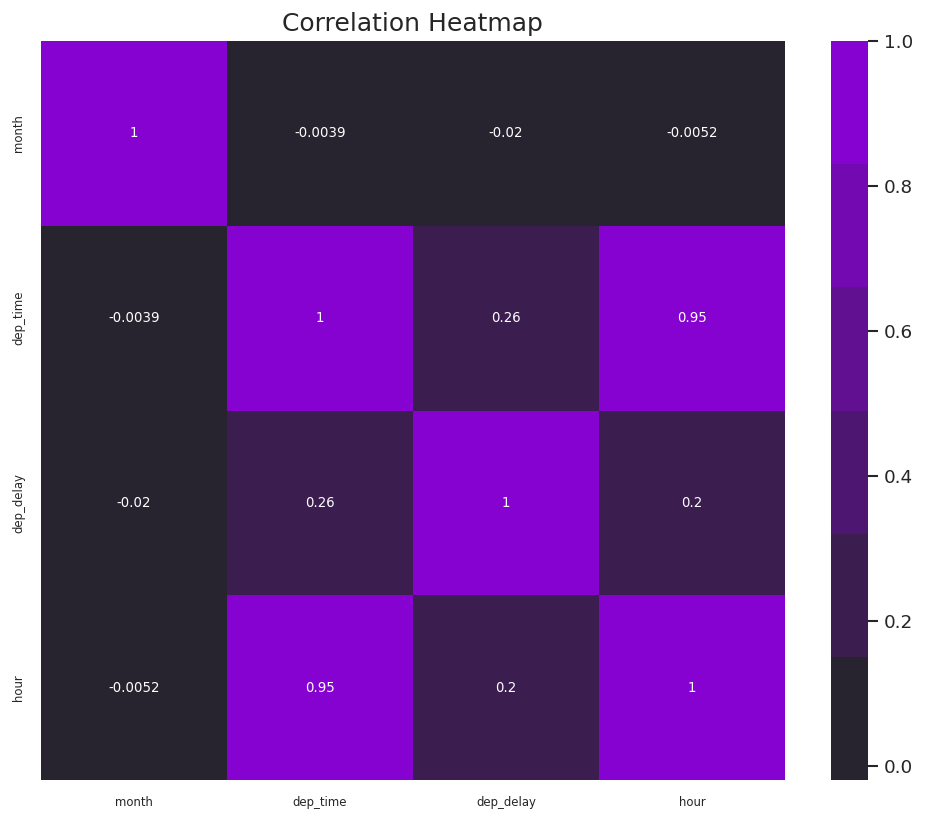

In [43]:
# Define color palette with different shades of color #8502d1 for multivariate plots
colors_multi = sns.dark_palette("#8502d1", as_cmap=False)

# For correlation heatmap, let's consider the numeric features only
numeric_features = ['month', 'dep_time', 'dep_delay', 'hour']
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap=colors_multi, annot_kws={"size": 8})
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)
plt.title('Correlation Heatmap', fontsize=15)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>
    
The heatmap shows the correlation coefficients between the numeric features. `dep_delay` has a strong positive correlation with `arr_delay`, which means that as the departure delay increases, the arrival delay also tends to increase. The other features (`month`, `dep_time`, and `hour`) show very weak correlations with `arr_delay`, suggesting that these features by themselves do not strongly influence the arrival delay.

### <b><span style='color:darkorange'>Step 4.3.2 |</span><span style='color:#8502d1'> dep_delay vs dep_time across different carrier</span></b>

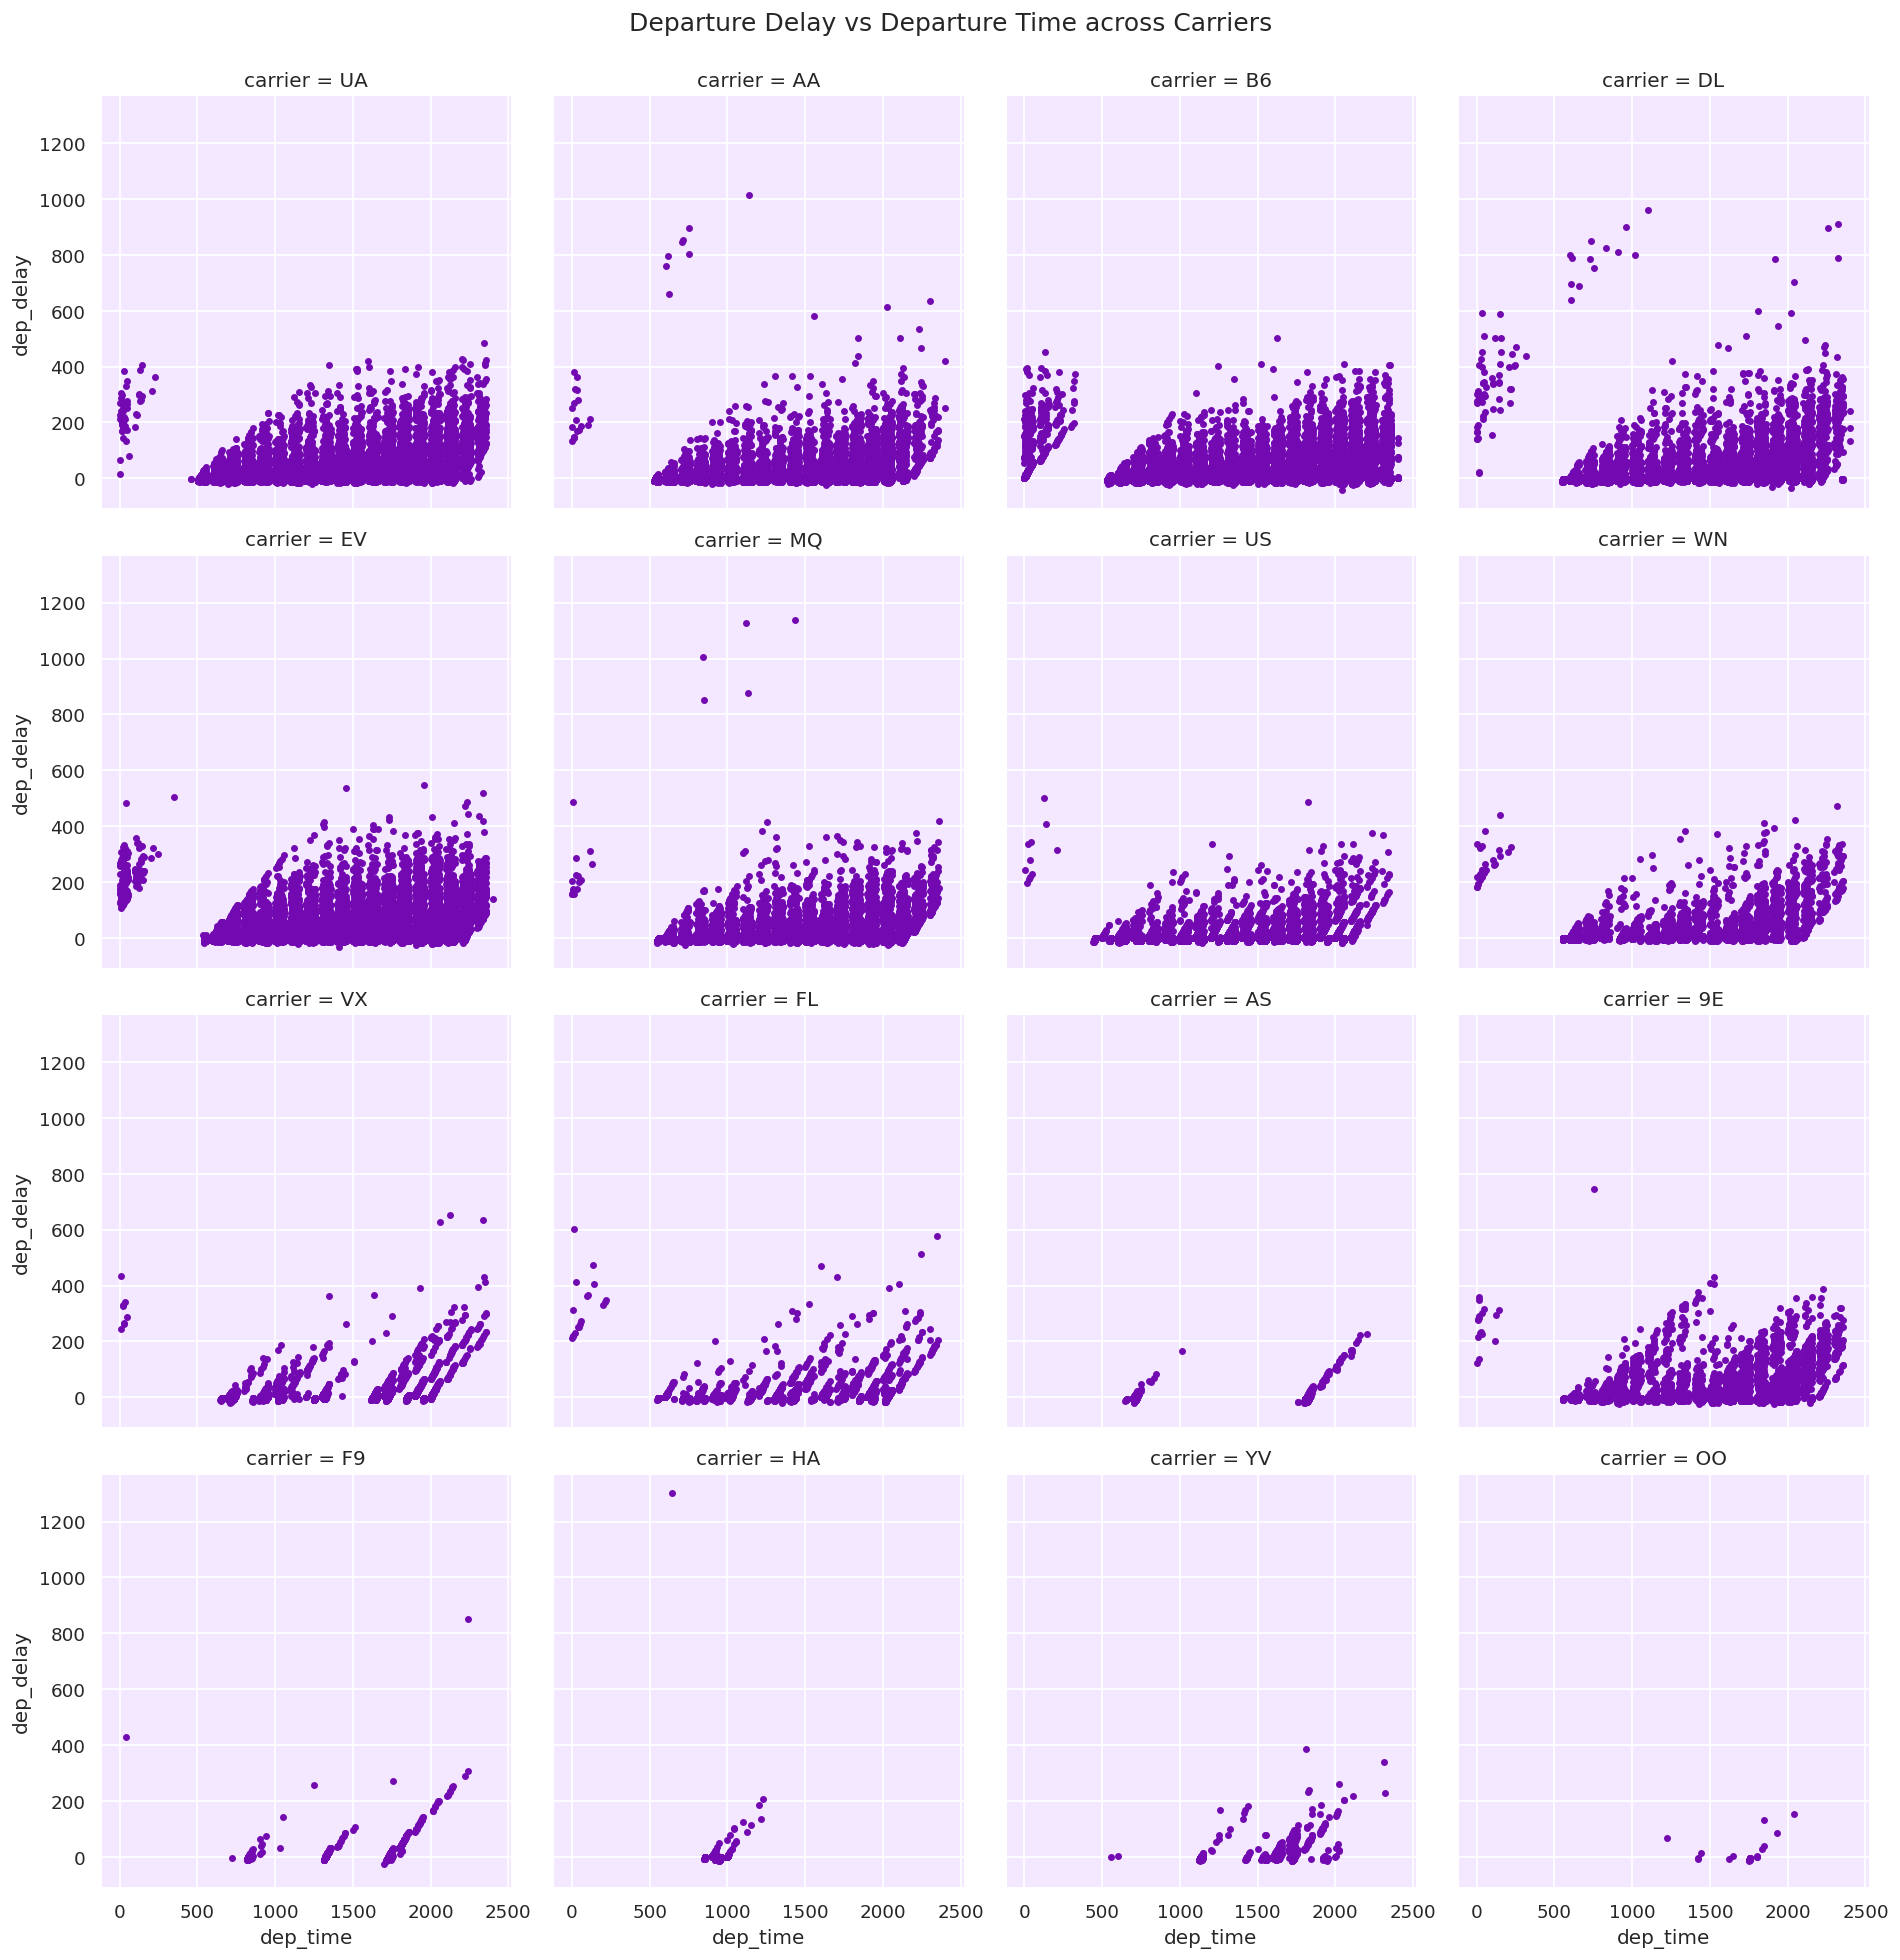

In [44]:
# 'dep_delay' vs 'dep_time' across different 'carrier'
g = sns.FacetGrid(df, col="carrier", col_wrap=4, height=4, aspect=1)
g.map(plt.scatter, "dep_time", "dep_delay", color=colors_multi[-2], s=10)
g.fig.suptitle('Departure Delay vs Departure Time across Carriers', fontsize=15, y=1.02)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

These scatter plots show the relationship between departure delay and departure time for different carriers. Some carriers show a more pronounced trend of increased departure delay with later departure times, while others do not. This suggests that the interaction between carrier and departure time could be a significant factor influencing arrival delay.

### <b><span style='color:darkorange'>Step 4.3.3 |</span><span style='color:#8502d1'> dep_delay vs dep_time across different origin</span></b>

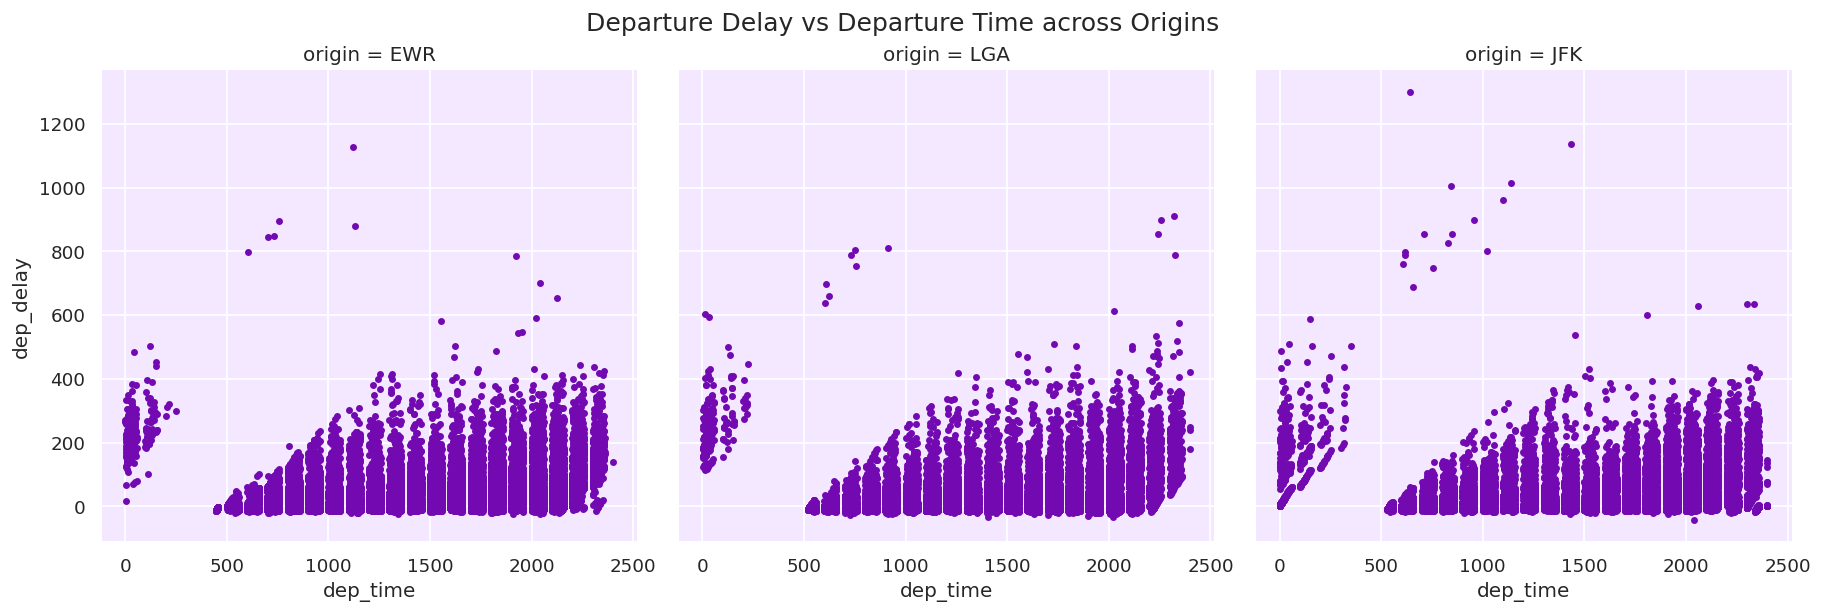

In [45]:
# 'dep_delay' vs 'dep_time' across different 'origin'
g = sns.FacetGrid(df, col="origin", col_wrap=4, height=5, aspect=1)
g.map(plt.scatter, "dep_time", "dep_delay", color=colors_multi[-2], s=10)
g.fig.suptitle('Departure Delay vs Departure Time across Origins', fontsize=15, y=1.02, x=0.38)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Inference:</font></h2>

These scatter plots show the relationship between departure delay and departure time for flights from different origins. Similar to the carrier plots, some origin airports show a more pronounced trend of increased departure delay with later departure times, while others do not. This suggests that the interaction between origin airport and departure time could also be a significant factor influencing arrival delay.

<a id="preprocessing"></a>
# <p style="background-color:#8502d1; font-family:calibri; color:white; font-size:150%; text-align:center; border-radius:15px 50px;">Step 5 | Data Preprocessing</p>

⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Data preprocessing is a crucial step in any machine learning project. It involves cleaning and transforming raw data into a format that can be understood by machine learning algorithms.

<a id="removal"></a>
# <b><span style='color:darkorange'>Step 5.1 |</span><span style='color:#8502d1'> Irrelevant Feature Removal</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Based on our careful review and exploratory data analysis so far, here's a rundown of each feature I am going to take out of the picture:
    
- __`id`__: This is a unique identifier assigned to each flight record in the dataset. It carries no informational value for the model, as it does not reflect any characteristic of the flights. 

- __`year`__: All the flights took place in 2013, so this feature is a constant for all records. A constant feature cannot improve the model's performance, because it does not contribute any information that can help distinguish one record from another.

- __`flight`__: This feature represents the designated number of the flight. However, there are many unique flight numbers (3844), which could lead to overfitting. Each flight number corresponds to a specific route, and while it's true that some routes may be more prone to delays than others, the high dimensionality of this feature may be more harmful than helpful.

- __`tailnum`__: This feature is a unique identifier associated with each aircraft used for the flight. There are even more unique tail numbers (4043) than there are unique flight numbers. Although certain aircraft may be more prone to delays (e.g., older planes that require more maintenance), again, the high dimensionality of this feature may lead to overfitting.

- __`time_hour`__: This feature represents the scheduled departure time of the flight, formatted as "yyyy-mm-dd hh:mm:ss". Since we have separate features for the year, month, day, and scheduled departure time (in the form of `sched_dep_time`), this feature is redundant and should be removed.

- __`minute`__: This feature represents the minute component of the scheduled departure time. We already have `sched_dep_time` that includes this information. Hence, `minute` can be removed.

- __`hour`__: Similar to `minute`, this feature is also redundant as we already have `sched_dep_time`. So `hour` should be removed as well.

- __`carrier`__: This is a two-letter code representing the airline carrier responsible for the flight. We have another feature, `name`, which represents the same information but in a more descriptive form (the full name of the airline carrier). To avoid redundancy, we can remove `carrier` and keep `name`.

In [46]:
df.drop(['id', 'year', 'flight', 'tailnum', 'time_hour', 'minute', 'hour', 'carrier'], axis=1, inplace=True)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
Let us check the list of remaining features:

In [47]:
df.columns

Index(['month', 'day', 'dep_time', 'sched_dep_time', 'dep_delay', 'arr_time',
       'sched_arr_time', 'arr_delay', 'origin', 'dest', 'air_time', 'distance',
       'name'],
      dtype='object')

____
<a id="missing"></a>
# <b><span style='color:darkorange'>Step 5.2 |</span><span style='color:#8502d1'>  Missing Value Treatment</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
__Missing data__ can disrupt many machine learning algorithms. It's crucial to handle these appropriately. Depending on the nature of the data and the percentage of missing values, we can:

* Drop the rows or columns with missing data, especially if the percentage of missing data is very high.
* Fill the missing data with a central tendency measure (mean, median, or mode).
* Predict the missing values using a machine learning algorithm like KNN.
* Use algorithms that can handle missing values.

In [48]:
# Check the percentage of missing values in each column
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
print("Missing Value Percentage by Columns:\n", round(missing_percent,2))

Missing Value Percentage by Columns:
 arr_delay         2.80
air_time          2.80
arr_time          2.59
dep_time          2.45
dep_delay         2.45
month             0.00
day               0.00
sched_dep_time    0.00
sched_arr_time    0.00
origin            0.00
dest              0.00
distance          0.00
name              0.00
dtype: float64


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Some of the missing values belong to the __target column__ (__`arr_delay`__). So, first I am going to drop rows with missing target values (`arr_delay`) to avoid introducing bias into our model. This is because we want our model to learn from actual observations, not from imputed values:

In [49]:
df.dropna(subset=['arr_delay'], inplace=True)
df.reset_index(drop=True, inplace=True)

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
Then i am using a __K-Nearest Neighbors (KNN) Imputer__ to fill in missing values in other columns. The KNN imputer is a more advanced imputation method that fills missing values based on similar observations, rather than just using the mean or median. This allows us to capture more complex patterns in the data, potentially leading to more accurate imputations:  

In [50]:
# Separate features and target
X = df.drop(columns=['arr_delay'])
y = df['arr_delay']

# Initialize the imputer
imputer = KNNImputer(n_neighbors=5)

# Apply the imputer
columns_to_impute = ['dep_time', 'dep_delay', 'arr_time', 'air_time']
X[columns_to_impute] = imputer.fit_transform(X[columns_to_impute])

# Check missing values again
X.isnull().sum().sum()

0

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

<h2 align="left"><font color=#8502d1>Note:</font></h2>

The separation of features and target before imputation ensures that our imputation process is not influenced by the target values, thereby preventing data leakage.

____
<a id="outlier"></a>
# <b><span style='color:darkorange'>Step 5.3 |</span><span style='color:#8502d1'>  Outlier Treatment</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

__Outliers__ are values that stand out from the rest because they're very different. They can sometimes cause problems, especially when we're doing something like __regression__, where outliers can have a big impact.

__In our flight delay data, these outliers represent the really long delays. These aren't errors or mistakes, they're a real part of flying that we want our model to learn from. So, we don't want to just throw these values away.__

But we also don't want these outliers to have too much influence. So, we use something called a __Box-Cox transformation__ later. __This is a way of adjusting our data to make the outliers less extreme, without getting rid of them.__

This way, our model can still learn from the outliers - the really long delays - but they won't have an outsized impact. And this is important because even though our model, regression, is usually sensitive to outliers, we still want it to learn from all parts of our data.

____
<a id="encoding"></a>
# <b><span style='color:darkorange'>Step 5.4 |</span><span style='color:#8502d1'> Categorical Features Encoding</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
Categorical variables need to be encoded because machine learning algorithms work with numerical data and cannot directly handle text or categorical data. First of all let's identify categorical columns:

In [51]:
# Identify categorical columns
cat_columns = X.select_dtypes(include=['object']).columns

# Check the number of unique categories in each categorical feature
X[cat_columns].nunique()

origin      3
dest      104
name       16
dtype: int64

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
We identified `origin`, `dest`, and `name` as __nominal categorical features__ (containing categories without any inherent order). Before proceeding with encoding, however, it would be helpful to check how balanced the categories are within each feature. For example, if a feature has a category that is very rarely present in the data, one-hot encoding could result in a column with mostly zeros, which might not be very informative for the model:

In [52]:
# Check the distribution of categories within each feature
for col in cat_columns:
    print(f"\nDistribution of categories in {col}:")
    print(X[col].value_counts())


Distribution of categories in origin:
EWR    117127
JFK    109079
LGA    101140
Name: origin, dtype: int64

Distribution of categories in dest:
ATL    16837
ORD    16566
LAX    16026
BOS    15022
MCO    13967
       ...  
HDN       14
MTJ       14
SBN       10
ANC        8
LEX        1
Name: dest, Length: 104, dtype: int64

Distribution of categories in name:
United Air Lines Inc.          57782
JetBlue Airways                54049
ExpressJet Airlines Inc.       51108
Delta Air Lines Inc.           47658
American Airlines Inc.         31947
Envoy Air                      25037
US Airways Inc.                19831
Endeavor Air Inc.              17294
Southwest Airlines Co.         12044
Virgin America                  5116
AirTran Airways Corporation     3175
Alaska Airlines Inc.             709
Frontier Airlines Inc.           681
Mesa Airlines Inc.               544
Hawaiian Airlines Inc.           342
SkyWest Airlines Inc.             29
Name: name, dtype: int64


<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">
    
Here's what we found:

* __`name`__: The `name` column has 16 unique categories, corresponding to different airline carriers. The distribution of categories is fairly balanced.
    
* __`origin`__: The `origin` column represents the airport from which the flight departed. There are 3 unique categories in this column, corresponding to three different airports. The distribution of categories is also quite balanced.

* __`dest`__ : The `dest` column represents the airport at which the flight arrived. There are 105 unique categories in this column, which is quite high. Some destinations have many flights (like ORD, ATL, LAX), while others have very few (like LEX, LGA).

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Based on the above observations, here's our plan for encoding:

* __One-hot Encoding__: We can apply one-hot encoding to the `origin`, and `name` columns. These columns have relatively few categories and are fairly balanced.


* __Frequency Encoding__: This method replaces each category in the feature with its frequency (i.e., the proportion of the total number of instances it represents). It's suitable for high-cardinality categorical features and does not introduce an arbitrary order. We will use this method for the `dest` feature, as it has a large number of unique categories, and the distribution is skewed, with some categories appearing much more frequently than others.

In [53]:
# Create a copy of the dataset for encoding
X_encoded = X.copy()

# Apply one-hot encoding to 'carrier', 'origin', and 'name'
X_encoded = pd.get_dummies(X_encoded, columns=['origin', 'name'], drop_first=True)

# Apply frequency encoding to 'dest'
dest_freq = X_encoded['dest'].value_counts() / len(X_encoded)  # calculate the frequencies
X_encoded['dest'] = X_encoded['dest'].map(dest_freq)  # map frequencies to the feature

# Show the result
X_encoded.head()

,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,dest,air_time,distance,...,name_ExpressJet Airlines Inc.,name_Frontier Airlines Inc.,name_Hawaiian Airlines Inc.,name_JetBlue Airways,name_Mesa Airlines Inc.,name_SkyWest Airlines Inc.,name_Southwest Airlines Co.,name_US Airways Inc.,name_United Air Lines Inc.,name_Virgin America
0,1,1,517.0,515,2.0,830.0,819,0.021644,227.0,1400,...,0,0,0,0,0,0,0,0,1,0
1,1,1,533.0,529,4.0,850.0,830,0.021644,227.0,1416,...,0,0,0,0,0,0,0,0,1,0
2,1,1,542.0,540,2.0,923.0,850,0.035415,160.0,1089,...,0,0,0,0,0,0,0,0,0,0
3,1,1,544.0,545,-1.0,1004.0,1022,0.002713,183.0,1576,...,0,0,0,1,0,0,0,0,0,0
4,1,1,554.0,600,-6.0,812.0,837,0.051435,116.0,762,...,0,0,0,0,0,0,0,0,0,0


____
<a id="time"></a>

# <b><span style='color:darkorange'>Step 5.5 |</span><span style='color:#8502d1'> Time Feature Transformation</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Time, especially when it's represented in the 24-hour format, has a cyclic nature. What this means is that 23:59 (or 2359 in the __hhmm__ format) and 00:01 (or 0001) are only two minutes apart, but if you look at their absolute difference in the __hhmm__ format, it would be 2358 units apart! This can be problematic for machine learning models that interpret numerical values in their raw form.

To address this, we can transform these time features into two dimensions using trigonometric functions, specifically __sine__ and __cosine__, to map each time to a point on a circle. This way, times that are close to each other on the 24-hour clock, such as 2359 and 0001, will also be close to each other on the circle.

____
__Example 1__: Consider the time 12:00 or 1200 in __hhmm__. This is exactly halfway through the day. If we map this onto a circle:
* The sine value would be 0 (because it's the horizontal midpoint).
* The cosine value would be 1 (the highest point on the upper circle).

    
__Example 2__: Now, for 18:00 or 1800, which is three-quarters of the way through the day:

* The sine value would be -1 (the lowest point on the bottom circle).
* The cosine value would again be 0.

By doing this transformation, we make sure times that are close on a clock are also close in the transformed feature space. 

In [54]:
# Time Feature Transformation
def transform_time(df, columns):
    for col in columns:
        df[col + '_sin'] = np.sin(2 * np.pi * df[col]/2400)
        df[col + '_cos'] = np.cos(2 * np.pi * df[col]/2400)
        df.drop(columns=col, inplace=True)
    return df

# List of 'hhmm' formatted features
time_cols = ['dep_time', 'sched_dep_time', 'arr_time', 'sched_arr_time']

# Apply transformation
X_encoded = transform_time(X_encoded, time_cols)

X_encoded.head()

,month,day,dep_delay,dest,air_time,distance,origin_JFK,origin_LGA,name_Alaska Airlines Inc.,name_American Airlines Inc.,...,name_United Air Lines Inc.,name_Virgin America,dep_time_sin,dep_time_cos,sched_dep_time_sin,sched_dep_time_cos,arr_time_sin,arr_time_cos,sched_arr_time_sin,sched_arr_time_cos
0,1,1,2.0,0.021644,227.0,1400,0,0,0,0,...,1,0,0.976485,0.215588,0.975342,2.206974e-01,0.824126,-0.566406,0.840094,-0.542442
1,1,1,4.0,0.021644,227.0,1416,0,1,0,0,...,1,0,0.984656,0.174508,0.982774,1.848091e-01,0.793353,-0.608761,0.824126,-0.566406
2,1,1,2.0,0.035415,160.0,1089,1,0,0,1,...,0,0,0.988494,0.151261,0.987688,1.564345e-01,0.663273,-0.748377,0.793353,-0.608761
3,1,1,-1.0,0.002713,183.0,1576,1,0,0,0,...,0,0,0.989272,0.146083,0.989651,1.434926e-01,0.490904,-0.871214,0.449319,-0.893371
4,1,1,-6.0,0.051435,116.0,762,0,1,0,0,...,0,0,0.992757,0.120137,1.000000,6.123234e-17,0.849893,-0.526956,0.813608,-0.581413


____
<a id="scaling"></a>

# <b><span style='color:darkorange'>Step 5.6 |</span><span style='color:#8502d1'> Feature Scaling</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

__Feature Scaling__, also known as __standardization__ or __normalization__, is a crucial preprocessing step for many machine learning algorithms. It adjusts the range of feature values so that they can be compared on a common scale. __This adjustment is particularly important for algorithms that rely on the magnitude or distance of the features__, such as __k-nearest neighbors (KNN)__, __support vector machines (SVMs)__, and __neural networks__.

When we perform feature scaling, we must avoid __data leakage__. This means that we should not let our scaling process be influenced by any data that isn't part of the training set. However, in our current scenario, we are using the entire dataset for training. Therefore, we can fit the scaler on the whole dataset.

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

Now, let's discuss our data. Now, we have different types of features in our dataset: __continuous features__, __categorical features that have been one-hot encoded or frequency encoded__, and __cyclic features that have been transformed from time data__.

For the continuous features, we'll use standard scaling (or Z-score normalization). This not only scales the features to a common range but also __handles outliers__ to a certain extent by centering the distribution around the mean with a unit standard deviation.

For the __categorical features__ that have been transformed through frequency encoding, we should also apply standard scaling. Even though these features originated as categorical data, the encoding has transformed them into continuous features that can take on a range of values.

As for the __binary features resulting from one-hot encoding, and cyclic features resulting from time transformation__, we don't need to apply scaling. Binary features already have values of 0 or 1, which are within the range of scaled data. Furthermore, applying scaling to binary features could distort their clear, interpretable structure. Cyclic features, on the other hand, have been engineered to capture the cyclical nature of time data, and scaling these could distort this cyclical pattern. 

In [55]:
# Define binary, cyclic, and continuous columns
binary_cols     = [col for col in X_encoded.columns if X_encoded[col].value_counts().index.isin([0,1]).all()] 
cyclic_cols     = [col for col in X_encoded.columns if col.endswith('_cos') or col.endswith('_sin')] 
continuous_cols = [col for col in X_encoded.columns if col not in binary_cols + cyclic_cols]

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the continuous features
X_encoded[continuous_cols] = scaler.fit_transform(X_encoded[continuous_cols])

# Show the result
X_encoded.head()

,month,day,dep_delay,dest,air_time,distance,origin_JFK,origin_LGA,name_Alaska Airlines Inc.,name_American Airlines Inc.,...,name_United Air Lines Inc.,name_Virgin America,dep_time_sin,dep_time_cos,sched_dep_time_sin,sched_dep_time_cos,arr_time_sin,arr_time_cos,sched_arr_time_sin,sched_arr_time_cos
0,-1.630263,-1.679414,-0.263447,-0.290559,0.814548,0.477816,0,0,0,0,...,1,0,0.976485,0.215588,0.975342,2.206974e-01,0.824126,-0.566406,0.840094,-0.542442
1,-1.630263,-1.679414,-0.213529,-0.290559,0.814548,0.499558,0,1,0,0,...,1,0,0.984656,0.174508,0.982774,1.848091e-01,0.793353,-0.608761,0.824126,-0.566406
2,-1.630263,-1.679414,-0.263447,0.558148,0.099410,0.055209,1,0,0,1,...,0,0,0.988494,0.151261,0.987688,1.564345e-01,0.663273,-0.748377,0.793353,-0.608761
3,-1.630263,-1.679414,-0.338324,-1.457249,0.344905,0.716977,1,0,0,0,...,0,0,0.989272,0.146083,0.989651,1.434926e-01,0.490904,-0.871214,0.449319,-0.893371
4,-1.630263,-1.679414,-0.463119,1.545420,-0.370233,-0.389140,0,1,0,0,...,0,0,0.992757,0.120137,1.000000,6.123234e-17,0.849893,-0.526956,0.813608,-0.581413


In [56]:
continuous_cols

['month', 'day', 'dep_delay', 'dest', 'air_time', 'distance']

____
<a id="boxcox"></a>
# <b><span style='color:darkorange'>Step 5.7 |</span><span style='color:#8502d1'> Transforming Skewed Features</span></b>

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

The __Box-Cox transformation__ is typically applied to features that are continuous and have a skewed distribution. The goal of this transformation is to modify these variables so they have a more normal or Gaussian-like distribution. Many machine learning models perform better with normally distributed data, so this transformation can be an important step in preprocessing.

The features we would consider for a Box-Cox transformation are ones that are:

* __Continuous in nature.__
* __Have a skewed distribution.__

    
This means we __should not apply the Box-Cox transformation to__:

* __Binary features__: These features only contain two unique values (0 and 1). Their distribution isn't suited for a Box-Cox transformation.
* __Cyclic features__: These features have already been transformed to handle their cyclic nature. They're not typically skewed because they take on values in a circle, so a Box-Cox transformation would not be suitable.
* __Discrete features__: Features such as `month` and `day` are discrete and not strictly continuous, so they wouldn't typically be transformed using Box-Cox.
    
    
From the list of continuous variables, the features `dep_delay`, `air_time`, and `distance` could potentially benefit from a Box-Cox transformation, as these might contain skewed data.

To decide if a feature needs a Box-Cox transformation, we can use a __histogram__ or a __Q-Q plot__ to check the distribution of the data. If the distribution is significantly skewed, then it's a candidate for the Box-Cox transformation.

In [57]:
# Define the function to plot histograms with specified color
def plot_hist(column, title, xlabel, color, bins=30):
    sns.histplot(column, bins=bins, color=color, edgecolor='white', kde=True)
    plt.title(title, fontsize=12)
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel('Frequency', fontsize=10)

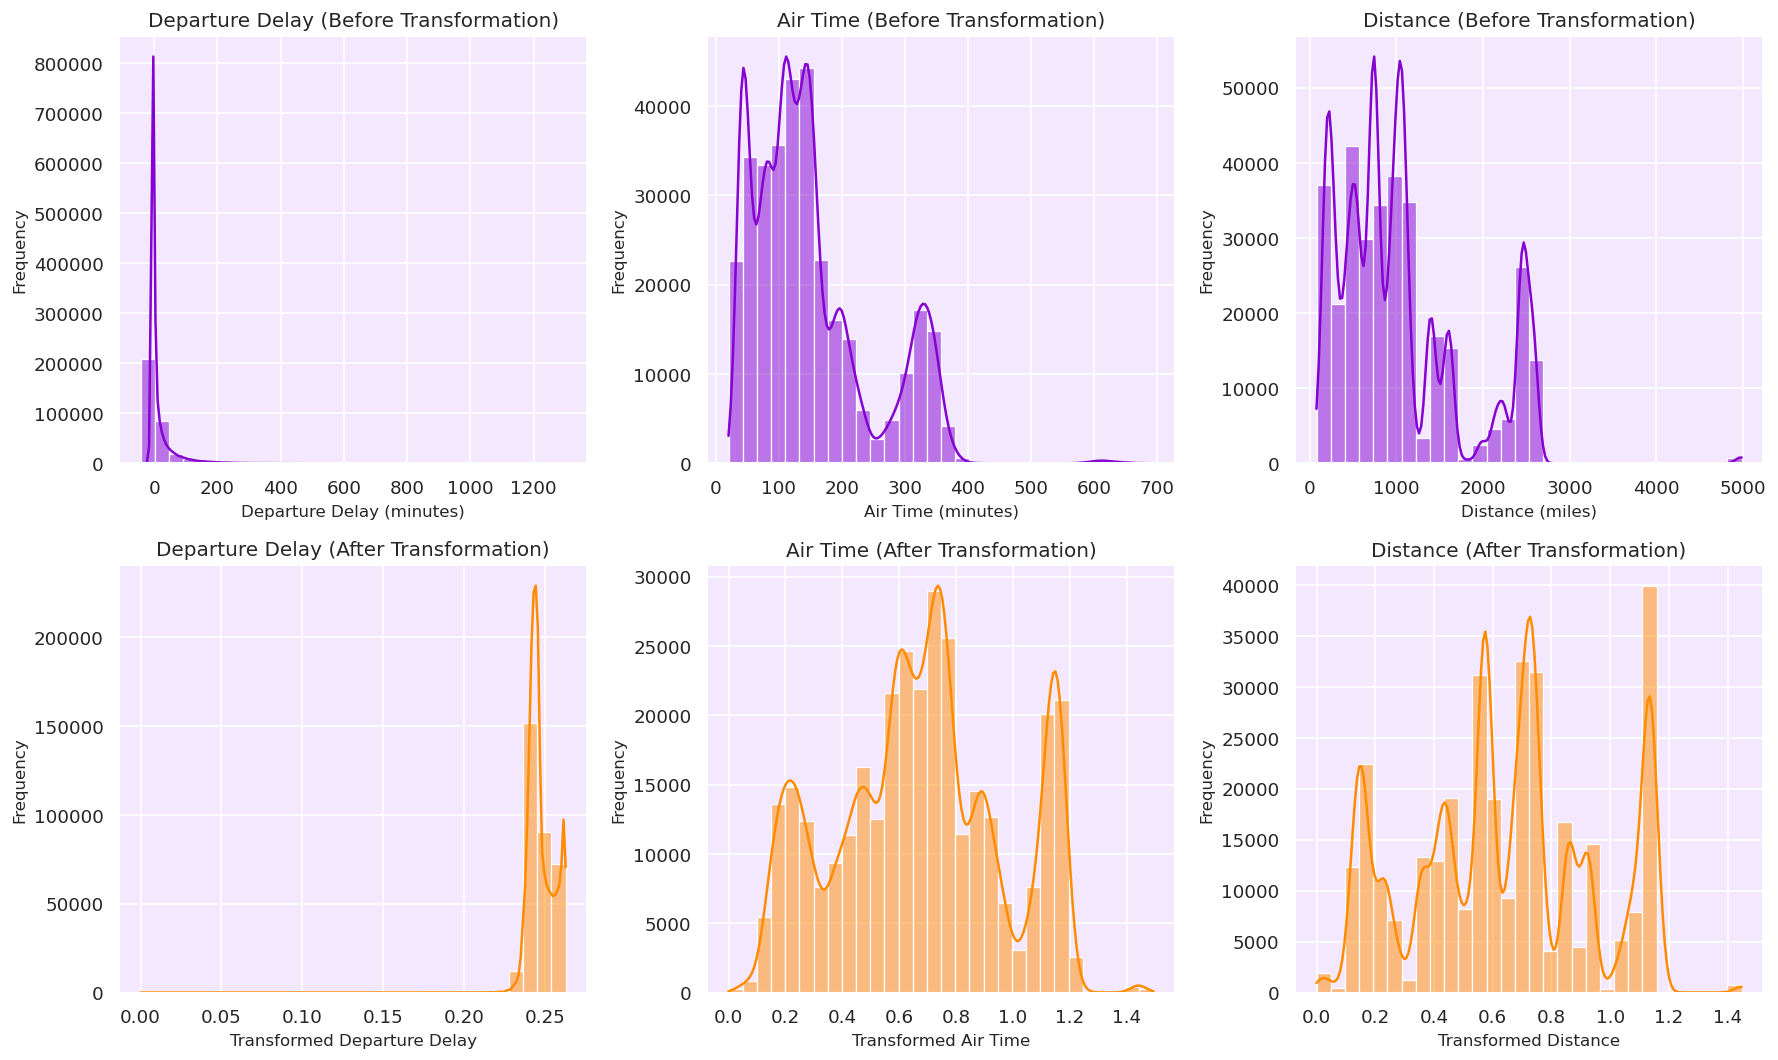

In [58]:
# Identify the features that might need a Box-Cox transformation
skewed_features = ['dep_delay', 'air_time', 'distance']

# Copy the dataset
X_transformed = X_encoded.copy()

# Apply Box-Cox transformation
for feature in skewed_features:
    # Adding a constant value to make all values positive
    X_transformed[feature] = X_transformed[feature] + abs(X_transformed[feature].min()) + 1
    X_transformed[feature], _ = stats.boxcox(X_transformed[feature])

    
# Plot histograms of 'dep_delay', 'air_time', and 'distance' before transformation
plt.figure(figsize=(15, 9))

plt.subplot(2, 3, 1)
plot_hist(df['dep_delay'], title='Departure Delay (Before Transformation)', xlabel='Departure Delay (minutes)', color='#8502d1')

plt.subplot(2, 3, 2)
plot_hist(df['air_time'], title='Air Time (Before Transformation)', xlabel='Air Time (minutes)', color='#8502d1')

plt.subplot(2, 3, 3)
plot_hist(df['distance'], title='Distance (Before Transformation)', xlabel='Distance (miles)', color='#8502d1')


# Plot histograms of 'dep_delay', 'air_time', and 'distance' after transformation
plt.subplot(2, 3, 4)
plot_hist(X_transformed['dep_delay'], title='Departure Delay (After Transformation)', xlabel='Transformed Departure Delay', color='darkorange')

plt.subplot(2, 3, 5)
plot_hist(X_transformed['air_time'], title='Air Time (After Transformation)', xlabel='Transformed Air Time', color='darkorange')

plt.subplot(2, 3, 6)
plot_hist(X_transformed['distance'], title='Distance (After Transformation)', xlabel='Transformed Distance', color='darkorange')

# Set global tick label size
plt.rcParams['xtick.labelsize'] = 'small'  # for x-axis
plt.rcParams['ytick.labelsize'] = 'small'  # for y-axis

plt.tight_layout()
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

The histograms above show the distributions of `dep_delay`, `air_time`, and `distance` before and after the __Box-Cox__ transformation. In the first row, you can see the original distributions, which are right-skewed. After applying the Box-Cox transformation (shown in the second row), the features become more normally distributed, which is desirable for many machine learning models. __This transformation helps manage the influence of outliers and extreme values in these features, allowing the models to better learn from the data.__

In [59]:
X_transformed.head()

,month,day,dep_delay,dest,air_time,distance,origin_JFK,origin_LGA,name_Alaska Airlines Inc.,name_American Airlines Inc.,...,name_United Air Lines Inc.,name_Virgin America,dep_time_sin,dep_time_cos,sched_dep_time_sin,sched_dep_time_cos,arr_time_sin,arr_time_cos,sched_arr_time_sin,sched_arr_time_cos
0,-1.630263,-1.679414,0.247770,-0.290559,0.959361,0.860244,0,0,0,0,...,1,0,0.976485,0.215588,0.975342,2.206974e-01,0.824126,-0.566406,0.840094,-0.542442
1,-1.630263,-1.679414,0.249037,-0.290559,0.959361,0.865612,0,1,0,0,...,1,0,0.984656,0.174508,0.982774,1.848091e-01,0.793353,-0.608761,0.824126,-0.566406
2,-1.630263,-1.679414,0.247770,0.558148,0.783470,0.743137,1,0,0,1,...,0,0,0.988494,0.151261,0.987688,1.564345e-01,0.663273,-0.748377,0.793353,-0.608761
3,-1.630263,-1.679414,0.245580,-1.457249,0.850771,0.916369,1,0,0,0,...,0,0,0.989272,0.146083,0.989651,1.434926e-01,0.490904,-0.871214,0.449319,-0.893371
4,-1.630263,-1.679414,0.240943,1.545420,0.625846,0.584809,0,1,0,0,...,0,0,0.992757,0.120137,1.000000,6.123234e-17,0.849893,-0.526956,0.813608,-0.581413


In [60]:
X_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327346 entries, 0 to 327345
Data columns (total 31 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   month                          327346 non-null  float64
 1   day                            327346 non-null  float64
 2   dep_delay                      327346 non-null  float64
 3   dest                           327346 non-null  float64
 4   air_time                       327346 non-null  float64
 5   distance                       327346 non-null  float64
 6   origin_JFK                     327346 non-null  uint8  
 7   origin_LGA                     327346 non-null  uint8  
 8   name_Alaska Airlines Inc.      327346 non-null  uint8  
 9   name_American Airlines Inc.    327346 non-null  uint8  
 10  name_Delta Air Lines Inc.      327346 non-null  uint8  
 11  name_Endeavor Air Inc.         327346 non-null  uint8  
 12  name_Envoy Air                

<div style="border-radius:10px; padding: 15px; background-color: #e2c9ff; font-size:110%; text-align:left">

We've tidied up our data and it's now looking great! It's prepped, primed, and ready to dive into the world of machine learning models. Let the training begin!

<h2 align="left"><font color='#8502d1'>Best Regards!</font></h2>